In [1]:
import numpy as np
from scipy.interpolate import interp1d
from scipy.interpolate import RegularGridInterpolator
from scipy.interpolate import LinearNDInterpolator
from matplotlib import rcParams
rcParams['text.usetex'] = True
rcParams["font.family"] = "Times New Roman"
import matplotlib.pyplot as plt
import math as mth
from IPython.display import display, Math

# Visualizing the Datasets

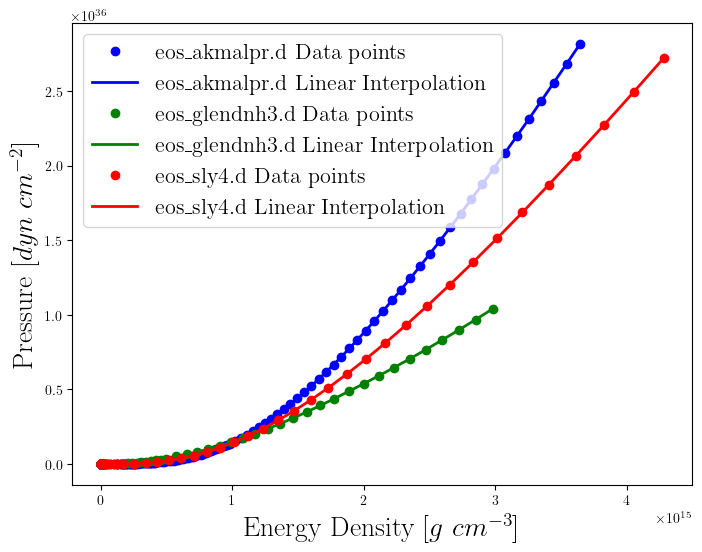

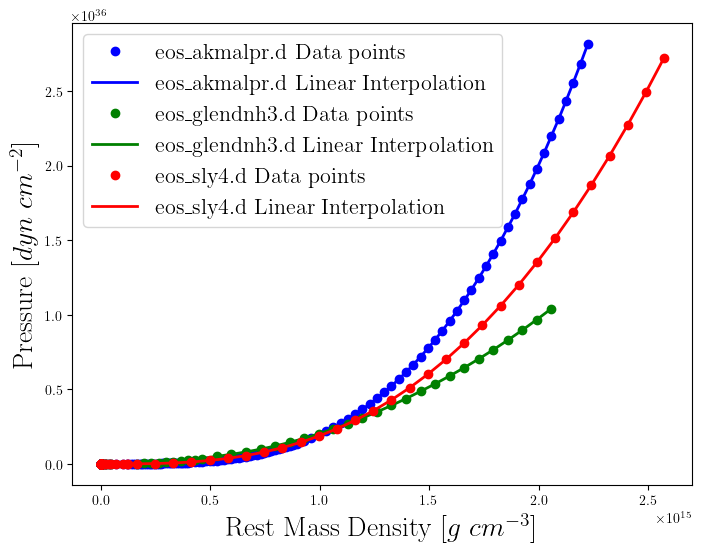

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

file_paths = ['eos_akmalpr.d', 'eos_glendnh3.d', 'eos_sly4.d']

data_dict = {}

for file_path in file_paths:
    data = np.loadtxt(file_path, skiprows=7)
    Rho = data[:, 1] * 1e+39 * 1.66e-24
    Pressure = data[:, 3] 
    Epsilon = data[:, 2] 
    Pressure_function = interp1d(Epsilon, Pressure, kind='linear', fill_value='extrapolate')
    Pressure_Rho_function = interp1d(Rho, Pressure, kind='linear', fill_value='extrapolate')
    Rho_function = interp1d(Pressure, Rho, kind='linear', fill_value='extrapolate')
    data_dict[file_path] = (Epsilon, Pressure, Pressure_function, Rho, Pressure_Rho_function)

# Plotting Pressure vs Energy Density
plt.figure(figsize=(8, 6))
colors = ['b', 'g', 'r']

for i, (file_path, (Epsilon, Pressure, Pressure_function, Rho, Rho_function)) in enumerate(data_dict.items()):
    plt.plot(Epsilon, Pressure, f'{colors[i]}o', label=f'{file_path} Data points', markersize=6)
    plt.plot(Epsilon, Pressure_function(Epsilon), f'{colors[i]}-', label=f'{file_path} Linear Interpolation', markersize=8, linewidth=2)

plt.xlabel('Energy Density [$ g\ cm^{-3} $]', fontsize=20)
plt.ylabel('Pressure [$dyn\ cm^{-2}$]', fontsize=20)
plt.legend(fontsize=16)  # Increase font size for legend here
# plt.title('Pressure vs Energy Density for Multiple Datasets')
plt.savefig('Dataset_P_ESP.pdf', format='pdf', bbox_inches="tight")
plt.show()


# Plotting Rest Mass Density vs Pressure
plt.figure(figsize=(8, 6))

for i, (file_path, (Epsilon, Pressure, Pressure_function, Rho, Pressure_Rho_function)) in enumerate(data_dict.items()):
    plt.plot(Rho, Pressure, f'{colors[i]}o', label=f'{file_path} Data points', markersize=6)
    plt.plot(Rho, Pressure_Rho_function(Rho), f'{colors[i]}-', label=f'{file_path} Linear Interpolation', linewidth=2)

plt.xlabel('Rest Mass Density [$ g\ cm^{-3} $]', fontsize=20)
plt.ylabel('Pressure [$dyn\ cm^{-2}$]', fontsize=20)
plt.legend(fontsize=16)  # Increase font size for legend here
# plt.title('Rest Mass Density vs Pressure for Multiple Datasets')
plt.savefig('Dataset_T_RHO.pdf', format='pdf', bbox_inches="tight")
plt.show()


# Tabular Equation of States

In [1]:
file_path = 'Causal_couple_0.1.dat'
data = np.loadtxt(file_path, skiprows=7)
Solar_mass_in_km = 1.47662504

Epsilon = []
Pressure = []
NB = []

for i in range(len(data)):
    #NB.append(data[i][1])
    Epsilon.append(data[i][1] * 7.4237 * (1e-19))  # Convert to Geometric Units
    Pressure.append(data[i][0] * 8.2601 * (1e-40))  # Convert to Geometric Units

Rho = np.array(NB) * 1e+54 * 1.66e-24 * 7.4237e-34  # Convert NB to Geometric Units

Pressure_function = interp1d(Epsilon, Pressure, kind='linear', fill_value='extrapolate')
Energy_Density_function = interp1d(Pressure, Epsilon, kind='linear', fill_value='extrapolate')
Rho_function = interp1d(Pressure, Rho, kind='linear', fill_value='extrapolate')

def dmdr(Epsilon, Radius):
    return 4 * mth.pi * Epsilon * (Radius ** 2)

def dpdr(Epsilon, Pressure, Mass, Radius):
    return (-(Epsilon + Pressure) * (Mass + (4 * mth.pi * (Radius ** 3) * Pressure))) / (Radius * (Radius - (2 * Mass)))

def dMdr(Epsilon, Mass, Radius):
    return 4 * mth.pi * Epsilon * (Radius ** 2) * ((1 - 2 * Mass / Radius) ** (-1 / 2))

def Mb0(rho0, m0, r0):
    M = [m0]
    r = r0
    i = 0
    h = 0.005  # Step size
    while r <= r0:
        K_Mass_B_1 = dMdr(rho0, m0, r)
        K_Mass_B_2 = dMdr(rho0, m0, r + 0.5 * h)
        K_Mass_B_3 = dMdr(rho0, m0, r + 0.5 * h)
        K_Mass_B_4 = dMdr(rho0, m0, r + h)
        m = M[i] + ((1 / 6) * (K_Mass_B_1 + 2 * K_Mass_B_2 + 2 * K_Mass_B_3 + K_Mass_B_4))
        M.append(m)
        r += h
        i += 1
    return M[-1]

def RK4_Slope(Mass, MassB, Pressure, Epsilon, Rho, Radius, h):
    k_Mass_1 = dmdr(Epsilon, Radius)
    k_Mass_B_1 = dMdr(Rho, Mass, Radius)
    k_Pressure_1 = dpdr(Epsilon, Pressure, Mass, Radius)
    k_Epsilon_1 = Energy_Density_function(Pressure)
    k_Rho_1 = Rho_function(Pressure)

    k_Mass_2 = dmdr(Epsilon + 0.5 * h * k_Epsilon_1, Radius + 0.5 * h)
    k_Mass_B_2 = dMdr(Rho + 0.5 * h * k_Rho_1, Mass + 0.5 * h * k_Mass_1, Radius + 0.5 * h)
    k_Pressure_2 = dpdr(Epsilon + 0.5 * h * k_Epsilon_1, Pressure + 0.5 * h * k_Pressure_1, Mass + 0.5 * h * k_Mass_1, Radius + 0.5 * h)
    k_Epsilon_2 = Energy_Density_function(Pressure + 0.5 * h * k_Pressure_1)
    k_Rho_2 = Rho_function(Pressure + 0.5 * h * k_Pressure_1)

    k_Mass_3 = dmdr(Epsilon + 0.5 * h * k_Epsilon_2, Radius + 0.5 * h)
    k_Mass_B_3 = dMdr(Rho + 0.5 * h * k_Rho_2, Mass + 0.5 * h * k_Mass_2, Radius + 0.5 * h)
    k_Pressure_3 = dpdr(Epsilon + 0.5 * h * k_Epsilon_2, Pressure + 0.5 * h * k_Pressure_2, Mass + 0.5 * h * k_Mass_2, Radius + 0.5 * h)
    k_Epsilon_3 = Energy_Density_function(Pressure + 0.5 * h * k_Pressure_2)
    k_Rho_3 = Rho_function(Pressure + 0.5 * h * k_Pressure_2)

    k_Mass_4 = dmdr(Epsilon + h * k_Epsilon_3, Radius + h)
    k_Mass_B_4 = dMdr(Rho + h * k_Rho_3, Mass + h * k_Mass_3, Radius + h)
    k_Pressure_4 = dpdr(Epsilon + h * k_Epsilon_3, Pressure + h * k_Pressure_3, Mass + h * k_Mass_3, Radius + h)
    k_Epsilon_4 = Energy_Density_function(Pressure + h * k_Pressure_3)
    k_Rho_4 = Rho_function(Pressure + h * k_Pressure_3)

    return [(1 / 6) * (k_Mass_1 + 2 * k_Mass_2 + 2 * k_Mass_3 + k_Mass_4),
            (1 / 6) * (k_Mass_B_1 + 2 * k_Mass_B_2 + 2 * k_Mass_B_3 + k_Mass_B_4),
            (1 / 6) * (k_Pressure_1 + 2 * k_Pressure_2 + 2 * k_Pressure_3 + k_Pressure_4),
            (1 / 6) * (k_Epsilon_1 + 2 * k_Epsilon_2 + 2 * k_Epsilon_3 + k_Epsilon_4),
            (1 / 6) * (k_Rho_1 + 2 * k_Rho_2 + 2 * k_Rho_3 + k_Rho_4)]

# Initial conditions
Epsilon0 = 58.68e-5                               # Geometric Unit
Pressure0 = Pressure_function(Epsilon0)
Rho0 = Rho_function(Pressure0)
Radius0 = 0.01                                        # Geometric Unit
Mass0 = (4 / 3) * mth.pi * (Radius0 ** 3) * Epsilon0  # Geometric Unit
h = 0.005
Pressure_Limit = 10 ** (-14)
MassB0 = Mb0(Rho0, Mass0, Radius0) #Mass0 

MassB = [MassB0]
Mass = [Mass0]
Pressure = [Pressure0]
Epsilon = [Epsilon0]
Radius = [Radius0]
Rho = [Rho0]

# RK4 integration
while Pressure[-1] > Pressure_Limit:
    Coefficient = RK4_Slope(Mass[-1], MassB[-1], Pressure[-1], Epsilon[-1], Rho[-1], Radius[-1], h)
    Mass_i = Mass[-1] + h * Coefficient[0]
    MassB_i = MassB[-1] + h * Coefficient[1]
    Pressure_i = Pressure[-1] + h * Coefficient[2]
    Epsilon_i = Energy_Density_function(Pressure_i)
    Rho_i = Rho_function(Pressure_i)
    Radius_i = Radius[-1] + h

    MassB.append(MassB_i)
    Mass.append(Mass_i)
    Pressure.append(Pressure_i)
    Epsilon.append(Epsilon_i)
    Radius.append(Radius_i)
    Rho.append(Rho_i)

# Final results
MassB_star = MassB[-1]
Mass_star = Mass[-1]
Radius_star = Radius[-1]

print(f'Baryonic Mass of star: {MassB_star / Solar_mass_in_km} Solar masses')
print(f'Mass of star: {Mass_star / Solar_mass_in_km} Solar masses')
print(f'Radius of star: {Radius_star} km')

# Plotting results
Mass_1 = np.array(Mass)
Mass_2 = np.array(MassB)

plt.figure(figsize=(10, 6))
plt.plot(Radius, Mass_1 / Solar_mass_in_km, 'b-', label='Gravitational Mass')
plt.plot(Radius, Mass_2 / Solar_mass_in_km, 'r-', label='Baryonic Mass')
plt.xlabel('Radius (km)')
plt.ylabel('Mass (solar masses)')
plt.title('Mass vs Radius for eos_akmalpr Dataset')
# plt.savefig('Mass vs Radius for eos_akmalpr Dataset')
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(Radius, Epsilon, label='Energy Density')
plt.xlabel('Radius (km)')
plt.ylabel('Energy Density (in Geometric Unit)')
plt.title('Energy Density vs Radius for eos_akmalpr Dataset')
# plt.savefig('Energy Density vs Radius for eos_akmalpr Dataset')
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(Radius, Pressure, label='Pressure')
plt.xlabel('Radius (km)')
plt.ylabel('Pressure (in Geomtric Unit)')
plt.title('Pressure vs Radius for eos_akmalpr Dataset')
# plt.savefig('Pressure vs Radius for eos_akmalpr Dataset')
plt.show()


NameError: name 'np' is not defined

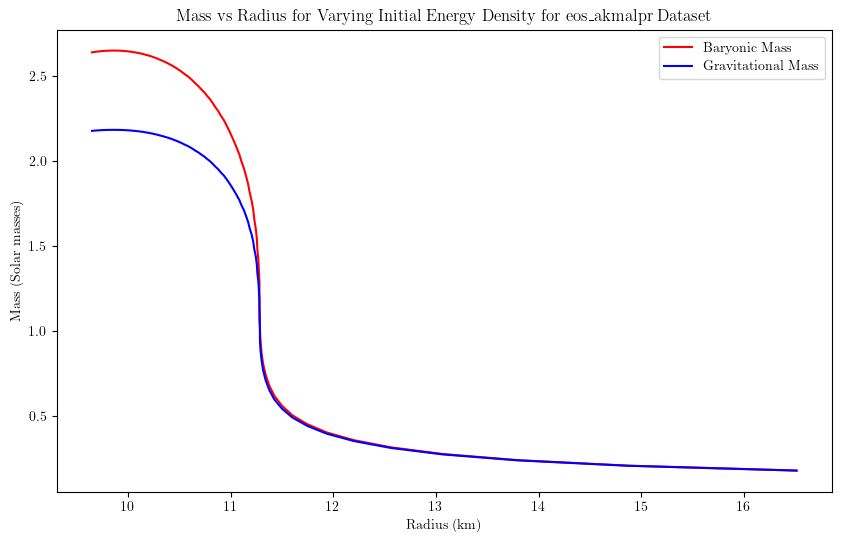

In [4]:
final_masses_a = []
final_radii_a = []
final_massb_a = []


Epsilon0_a = np.linspace(0.4, 4, 100) * 58.68e-5
Pressure0_a = np.array([Pressure_function(i) for i in Epsilon0_a])
Rho0_a = np.array([Rho_function(i) for i in Pressure0_a])

for n in Epsilon0_a:
    
    
    Epsilon0 = n  # Geometric Unit
    Pressure0 = Pressure_function(Epsilon0)
    Rho0 = Rho_function(Pressure0)
    Radius0 = 0.01  # Geometric Unit
    Mass0 = (4 / 3) * mth.pi * (Radius0 ** 3) * Epsilon0  # Geometric Unit
    h = 0.005
    Pressure_Limit = 10 ** (-14)
    MassB0 = Mb0(Rho0, Mass0, Radius0)


    MassB = [MassB0]
    Mass = [Mass0]
    Pressure = [Pressure0]
    Epsilon = [Epsilon0]
    Radius = [Radius0]
    Rho = [Rho0]

    
    while Pressure[-1] > Pressure_Limit:
        Coefficient = RK4_Slope(Mass[-1], MassB[-1], Pressure[-1], Epsilon[-1], Rho[-1], Radius[-1], h)
        Mass_i = Mass[-1] + h * Coefficient[0]
        MassB_i = MassB[-1] + h * Coefficient[1]
        Pressure_i = Pressure[-1] + h * Coefficient[2]
        Epsilon_i = Energy_Density_function(Pressure_i)
        Rho_i = Rho_function(Pressure_i)
        Radius_i = Radius[-1] + h

        MassB.append(MassB_i)
        Mass.append(Mass_i)
        Pressure.append(Pressure_i)
        Epsilon.append(Epsilon_i)
        Radius.append(Radius_i)
        Rho.append(Rho_i)

    final_massb_a.append(MassB[-1] / Solar_mass_in_km)
    final_masses_a.append(Mass[-1] / Solar_mass_in_km)
    final_radii_a.append(Radius[-1])


plt.figure(figsize=(10, 6))
plt.plot(final_radii_a, final_massb_a, 'r-', label='Baryonic Mass')
plt.plot(final_radii_a, final_masses_a, 'b-', label='Gravitational Mass')
plt.xlabel('Radius (km)')
plt.ylabel('Mass (Solar masses)')
plt.title('Mass vs Radius for Varying Initial Energy Density for eos_akmalpr Dataset')
plt.legend()
plt.show()

In [5]:
# MR_akmalpr = []
# for i in range(0,len(final_radii_a)):
#     Array_a = [Epsilon0_a[i], Rho0_a[i], Pressure0_a[i], final_masses_a[i], final_massb_a[i], final_radii_a[i]]
#     MR_akmalpr.append(Array)
# MR_akmalpr = np.array(MR_akmalpr)
# np.savetxt('MR_akmalpr_Geometric ', MR_akmalpr, delimiter = '\t', header = 'Epsilon0    Rho0    Pressure0    Gravitational Mass (Solar Masses)    Baryonic Mass (Solar Masses)    Radius' )

Baryonic Mass of star: 1.6750860558915925 Solar masses
Mass of star: 1.5355192316589865 Solar masses
Radius of star: 14.065000000000799 km


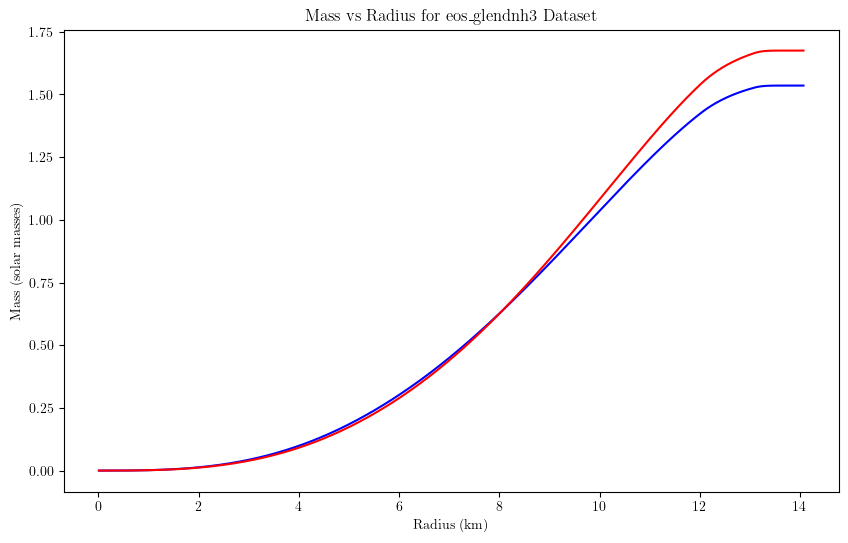

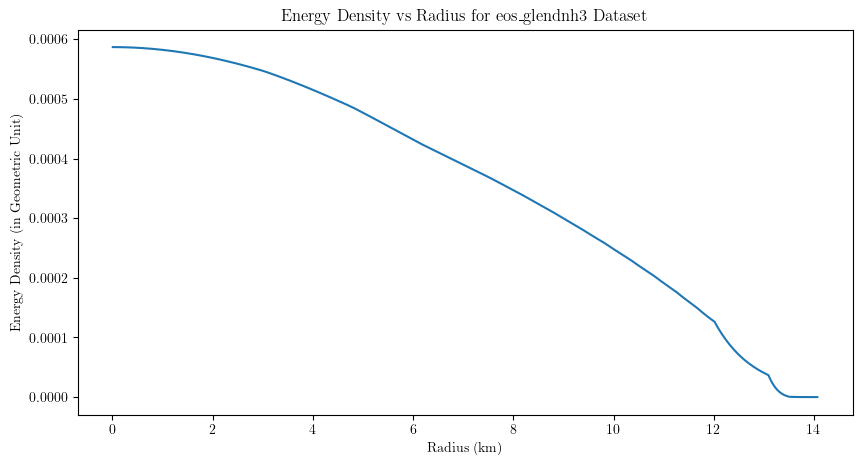

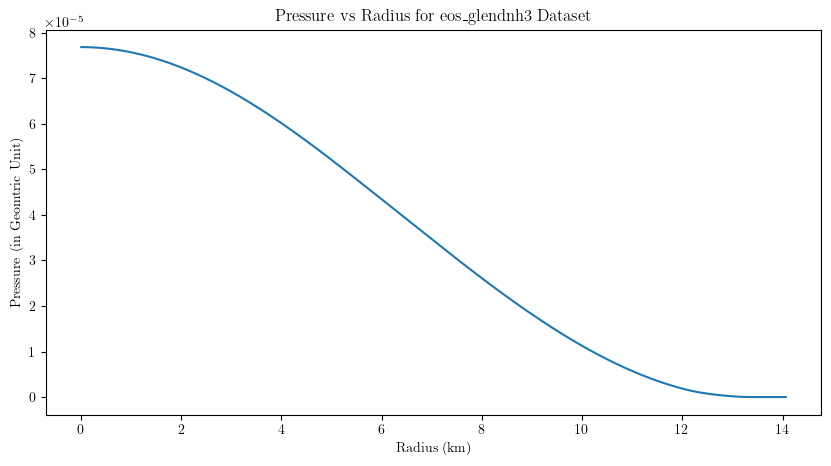

In [6]:
file_path = 'eos_glendnh3.d'
data = np.loadtxt(file_path, skiprows=7)
Solar_mass_in_km = 1.47662504

Epsilon = []
Pressure = []
NB = []

for i in range(len(data)):
    NB.append(data[i][1])
    Epsilon.append(data[i][2] * 7.4237 * (1e-19))  # Convert to Geometric Units
    Pressure.append(data[i][3] * 8.2601 * (1e-40))  # Convert to Geometric Units

Rho = np.array(NB) * 1e+54 * 1.66e-24 * 7.4237e-34  # Convert NB to Geometric Units

Pressure_function = interp1d(Epsilon, Pressure, kind='linear', fill_value='extrapolate')
Energy_Density_function = interp1d(Pressure, Epsilon, kind='linear', fill_value='extrapolate')
Rho_function = interp1d(Pressure, Rho, kind='linear', fill_value='extrapolate')

def dmdr(Epsilon, Radius):
    return 4 * mth.pi * Epsilon * (Radius ** 2)

def dpdr(Epsilon, Pressure, Mass, Radius):
    return (-(Epsilon + Pressure) * (Mass + (4 * mth.pi * (Radius ** 3) * Pressure))) / (Radius * (Radius - (2 * Mass)))

def dMdr(Rho, Mass, Radius):
    return 4 * mth.pi * Rho * (Radius ** 2) * ((1 - 2 * Mass / Radius) ** (-1 / 2))

def Mb0(rho0, m0, r0):
    M = [m0]
    r = r0
    i = 0
    h = 0.005  # Step size
    while r <= r0:
        K_Mass_B_1 = dMdr(rho0, m0, r)
        K_Mass_B_2 = dMdr(rho0, m0, r + 0.5 * h)
        K_Mass_B_3 = dMdr(rho0, m0, r + 0.5 * h)
        K_Mass_B_4 = dMdr(rho0, m0, r + h)
        m = M[i] + ((1 / 6) * (K_Mass_B_1 + 2 * K_Mass_B_2 + 2 * K_Mass_B_3 + K_Mass_B_4))
        M.append(m)
        r += h
        i += 1
    return M[-1]

def RK4_Slope(Mass, MassB, Pressure, Epsilon, Rho, Radius, h):
    k_Mass_1 = dmdr(Epsilon, Radius)
    k_Mass_B_1 = dMdr(Rho, Mass, Radius)
    k_Pressure_1 = dpdr(Epsilon, Pressure, Mass, Radius)
    k_Epsilon_1 = Energy_Density_function(Pressure)
    k_Rho_1 = Rho_function(Pressure)

    k_Mass_2 = dmdr(Epsilon + 0.5 * h * k_Epsilon_1, Radius + 0.5 * h)
    k_Mass_B_2 = dMdr(Rho + 0.5 * h * k_Rho_1, Mass + 0.5 * h * k_Mass_1, Radius + 0.5 * h)
    k_Pressure_2 = dpdr(Epsilon + 0.5 * h * k_Epsilon_1, Pressure + 0.5 * h * k_Pressure_1, Mass + 0.5 * h * k_Mass_1, Radius + 0.5 * h)
    k_Epsilon_2 = Energy_Density_function(Pressure + 0.5 * h * k_Pressure_1)
    k_Rho_2 = Rho_function(Pressure + 0.5 * h * k_Pressure_1)

    k_Mass_3 = dmdr(Epsilon + 0.5 * h * k_Epsilon_2, Radius + 0.5 * h)
    k_Mass_B_3 = dMdr(Rho + 0.5 * h * k_Rho_2, Mass + 0.5 * h * k_Mass_2, Radius + 0.5 * h)
    k_Pressure_3 = dpdr(Epsilon + 0.5 * h * k_Epsilon_2, Pressure + 0.5 * h * k_Pressure_2, Mass + 0.5 * h * k_Mass_2, Radius + 0.5 * h)
    k_Epsilon_3 = Energy_Density_function(Pressure + 0.5 * h * k_Pressure_2)
    k_Rho_3 = Rho_function(Pressure + 0.5 * h * k_Pressure_2)

    k_Mass_4 = dmdr(Epsilon + h * k_Epsilon_3, Radius + h)
    k_Mass_B_4 = dMdr(Rho + h * k_Rho_3, Mass + h * k_Mass_3, Radius + h)
    k_Pressure_4 = dpdr(Epsilon + h * k_Epsilon_3, Pressure + h * k_Pressure_3, Mass + h * k_Mass_3, Radius + h)
    k_Epsilon_4 = Energy_Density_function(Pressure + h * k_Pressure_3)
    k_Rho_4 = Rho_function(Pressure + h * k_Pressure_3)

    return [(1 / 6) * (k_Mass_1 + 2 * k_Mass_2 + 2 * k_Mass_3 + k_Mass_4),
            (1 / 6) * (k_Mass_B_1 + 2 * k_Mass_B_2 + 2 * k_Mass_B_3 + k_Mass_B_4),
            (1 / 6) * (k_Pressure_1 + 2 * k_Pressure_2 + 2 * k_Pressure_3 + k_Pressure_4),
            (1 / 6) * (k_Epsilon_1 + 2 * k_Epsilon_2 + 2 * k_Epsilon_3 + k_Epsilon_4),
            (1 / 6) * (k_Rho_1 + 2 * k_Rho_2 + 2 * k_Rho_3 + k_Rho_4)]

# Initial conditions
Epsilon0 = 58.68e-5                               # Geometric Unit
Pressure0 = Pressure_function(Epsilon0)
Rho0 = Rho_function(Pressure0)
Radius0 = 0.01                                        # Geometric Unit
Mass0 = (4 / 3) * mth.pi * (Radius0 ** 3) * Epsilon0  # Geometric Unit
h = 0.005
Pressure_Limit = 10 ** (-14)
MassB0 = Mb0(Rho0, Mass0, Radius0) #Mass0 

MassB = [MassB0]
Mass = [Mass0]
Pressure = [Pressure0]
Epsilon = [Epsilon0]
Radius = [Radius0]
Rho = [Rho0]

# RK4 integration
while Pressure[-1] > Pressure_Limit:
    Coefficient = RK4_Slope(Mass[-1], MassB[-1], Pressure[-1], Epsilon[-1], Rho[-1], Radius[-1], h)
    Mass_i = Mass[-1] + h * Coefficient[0]
    MassB_i = MassB[-1] + h * Coefficient[1]
    Pressure_i = Pressure[-1] + h * Coefficient[2]
    Epsilon_i = Energy_Density_function(Pressure_i)
    Rho_i = Rho_function(Pressure_i)
    Radius_i = Radius[-1] + h

    MassB.append(MassB_i)
    Mass.append(Mass_i)
    Pressure.append(Pressure_i)
    Epsilon.append(Epsilon_i)
    Radius.append(Radius_i)
    Rho.append(Rho_i)

# Final results
MassB_star = MassB[-1]
Mass_star = Mass[-1]
Radius_star = Radius[-1]

print(f'Baryonic Mass of star: {MassB_star / Solar_mass_in_km} Solar masses')
print(f'Mass of star: {Mass_star / Solar_mass_in_km} Solar masses')
print(f'Radius of star: {Radius_star} km')

# Plotting results
Mass_1 = np.array(Mass)
Mass_2 = np.array(MassB)

plt.figure(figsize=(10, 6))
plt.plot(Radius, Mass_1 / Solar_mass_in_km, 'b-', label='Gravitational Mass')
plt.plot(Radius, Mass_2 / Solar_mass_in_km, 'r-', label='Baryonic Mass')
plt.xlabel('Radius (km)')
plt.ylabel('Mass (solar masses)')
plt.title('Mass vs Radius for eos_glendnh3 Dataset')
# plt.savefig('Mass vs Radius of for eos_glendnh3 Dataset')
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(Radius, Epsilon, label='Energy Density')
plt.xlabel('Radius (km)')
plt.ylabel('Energy Density (in Geometric Unit)')
plt.title('Energy Density vs Radius for eos_glendnh3 Dataset')
# plt.savefig('Energy Density vs Radius for eos_glendnh3 Dataset')
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(Radius, Pressure, label='Pressure')
plt.xlabel('Radius (km)')
plt.ylabel('Pressure (in Geomtric Unit)')
plt.title('Pressure vs Radius for eos_glendnh3 Dataset')
# plt.savefig('Pressure vs Radius for eos_glendnh3 Dataset')
plt.show()


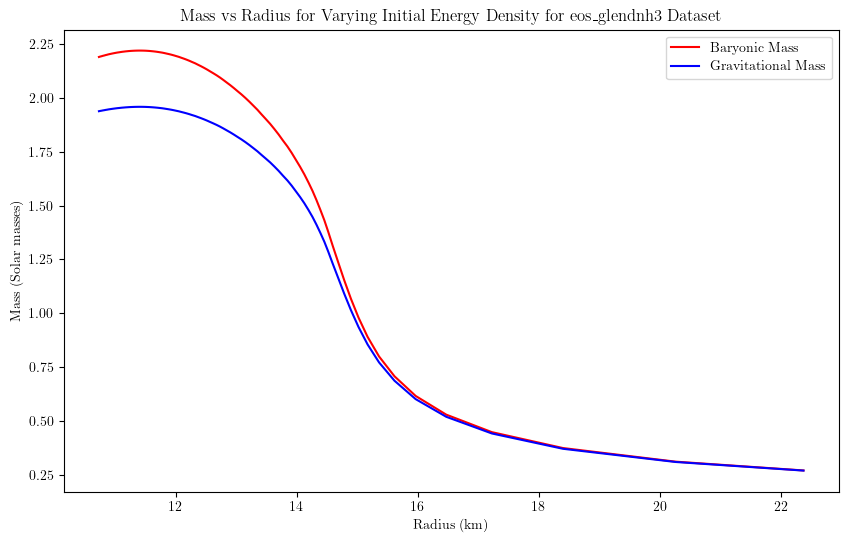

In [7]:
Solar_mass_in_km = 1.47662504
Epsilon0 = 58.68e-5  # Geometric Unit
Rho0 = 58.68e-5
Radius0 = 0.1  # Geometric Unit
Mass0 = (4 / 3) * (mth.pi) * (Radius0 ** 3) * Epsilon0  # Geometric Unit
Pressure0 = Pressure_function(Epsilon0)
h = 0.005
Pressure_Limit = 10 ** (-14)
MassB0 = Mb0(Mass0, Epsilon0, Radius0)

# Lists to store final results
final_masses_g = []
final_radii_g = []
final_massb_g = []


multipliers = np.linspace(0.2, 4, 100)


for n in multipliers:
    
    # Initial conditions
    Epsilon0 = 58.68e-5 * n  # Geometric Unit
    Pressure0 = Pressure_function(Epsilon0)
    Rho0 = Rho_function(Pressure0)
    Radius0 = 0.01  # Geometric Unit
    Mass0 = (4 / 3) * mth.pi * (Radius0 ** 3) * Epsilon0  # Geometric Unit
    h = 0.005
    Pressure_Limit = 10 ** (-14)
    MassB0 = Mb0(Rho0, Mass0, Radius0)


    MassB = [MassB0]
    Mass = [Mass0]
    Pressure = [Pressure0]
    Epsilon = [Epsilon0]
    Radius = [Radius0]
    Rho = [Rho0]

    
    while Pressure[-1] > Pressure_Limit:
        Coefficient = RK4_Slope(Mass[-1], MassB[-1], Pressure[-1], Epsilon[-1], Rho[-1], Radius[-1], h)
        Mass_i = Mass[-1] + h * Coefficient[0]
        MassB_i = MassB[-1] + h * Coefficient[1]
        Pressure_i = Pressure[-1] + h * Coefficient[2]
        Epsilon_i = Energy_Density_function(Pressure_i)
        Rho_i = Rho_function(Pressure_i)
        Radius_i = Radius[-1] + h

        MassB.append(MassB_i)
        Mass.append(Mass_i)
        Pressure.append(Pressure_i)
        Epsilon.append(Epsilon_i)
        Radius.append(Radius_i)
        Rho.append(Rho_i)

    final_massb_g.append(MassB[-1] / Solar_mass_in_km)
    final_masses_g.append(Mass[-1] / Solar_mass_in_km)
    final_radii_g.append(Radius[-1])


plt.figure(figsize=(10, 6))
plt.plot(final_radii_g, final_massb_g, 'r-', label='Baryonic Mass')
plt.plot(final_radii_g, final_masses_g, 'b-', label='Gravitational Mass')
plt.xlabel('Radius (km)')
plt.ylabel('Mass (Solar masses)')
plt.title('Mass vs Radius for Varying Initial Energy Density for eos_glendnh3 Dataset')
plt.legend()
plt.show()

In [8]:
# MR_glendnh3 = []
# for i in range(0,len(final_radii_g)):
#     Array_g = [Epsilon0_g[i], Rho0_g[i], Pressure0_g[i], final_masses_g[i], final_massb_g[i], final_radii_g[i]]
#     MR_glendnh3.append(Array_g)
# MR_glendnh3 = np.array(MR_glendnh3)
# np.savetxt('MR_glendnh3_Geometric ', MR_glendnh3, delimiter = '\t', header = 'Epsilon0    Rho0    Pressure0    Gravitational Mass (Solar Masses)    Baryonic Mass (Solar Masses)    Radius' )

Baryonic Mass of star: 1.190985791952139 Solar masses
Mass of star: 1.106245009125795 Solar masses
Radius of star: 11.825000000000449 km


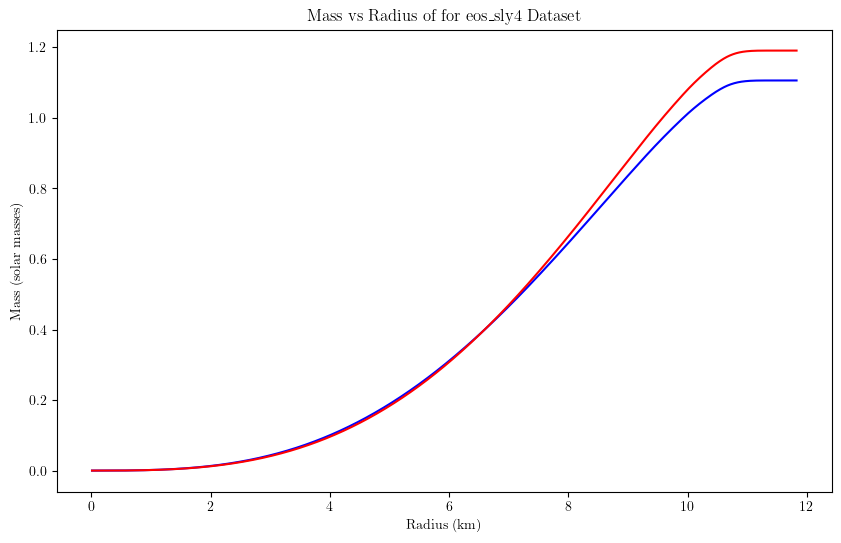

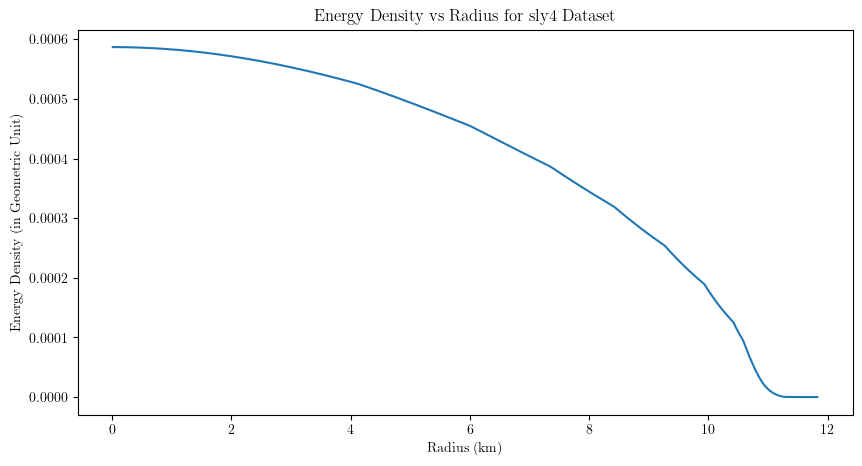

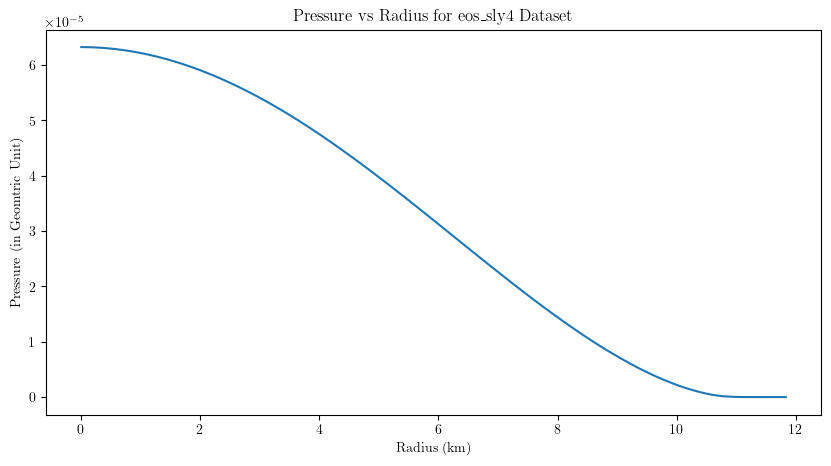

In [9]:
file_path = 'eos_sly4.d'
data = np.loadtxt(file_path, skiprows=7)
Solar_mass_in_km = 1.47662504

Epsilon = []
Pressure = []
NB = []

for i in range(len(data)):
    NB.append(data[i][1])
    Epsilon.append(data[i][2] * 7.4237 * (1e-19))  # Convert to Geometric Units
    Pressure.append(data[i][3] * 8.2601 * (1e-40))  # Convert to Geometric Units

Rho = np.array(NB) * 1e+54 * 1.66e-24 * 7.4237e-34  # Convert NB to Geometric Units

Pressure_function = interp1d(Epsilon, Pressure, kind='linear', fill_value='extrapolate')
Energy_Density_function = interp1d(Pressure, Epsilon, kind='linear', fill_value='extrapolate')
Rho_function = interp1d(Pressure, Rho, kind='linear', fill_value='extrapolate')

def dmdr(Epsilon, Radius):
    return 4 * mth.pi * Epsilon * (Radius ** 2)

def dpdr(Epsilon, Pressure, Mass, Radius):
    return (-(Epsilon + Pressure) * (Mass + (4 * mth.pi * (Radius ** 3) * Pressure))) / (Radius * (Radius - (2 * Mass)))

def dMdr(Rho, Mass, Radius):
    return 4 * mth.pi * Rho * (Radius ** 2) * ((1 - 2 * Mass / Radius) ** (-1 / 2))

def Mb0(rho0, m0, r0):
    M = [m0]
    r = r0
    i = 0
    h = 0.005  # Step size
    while r <= r0:
        K_Mass_B_1 = dMdr(rho0, m0, r)
        K_Mass_B_2 = dMdr(rho0, m0, r + 0.5 * h)
        K_Mass_B_3 = dMdr(rho0, m0, r + 0.5 * h)
        K_Mass_B_4 = dMdr(rho0, m0, r + h)
        m = M[i] + ((1 / 6) * (K_Mass_B_1 + 2 * K_Mass_B_2 + 2 * K_Mass_B_3 + K_Mass_B_4))
        M.append(m)
        r += h
        i += 1
    return M[-1]

def RK4_Slope(Mass, MassB, Pressure, Epsilon, Rho, Radius, h):
    k_Mass_1 = dmdr(Epsilon, Radius)
    k_Mass_B_1 = dMdr(Rho, Mass, Radius)
    k_Pressure_1 = dpdr(Epsilon, Pressure, Mass, Radius)
    k_Epsilon_1 = Energy_Density_function(Pressure)
    k_Rho_1 = Rho_function(Pressure)

    k_Mass_2 = dmdr(Epsilon + 0.5 * h * k_Epsilon_1, Radius + 0.5 * h)
    k_Mass_B_2 = dMdr(Rho + 0.5 * h * k_Rho_1, Mass + 0.5 * h * k_Mass_1, Radius + 0.5 * h)
    k_Pressure_2 = dpdr(Epsilon + 0.5 * h * k_Epsilon_1, Pressure + 0.5 * h * k_Pressure_1, Mass + 0.5 * h * k_Mass_1, Radius + 0.5 * h)
    k_Epsilon_2 = Energy_Density_function(Pressure + 0.5 * h * k_Pressure_1)
    k_Rho_2 = Rho_function(Pressure + 0.5 * h * k_Pressure_1)

    k_Mass_3 = dmdr(Epsilon + 0.5 * h * k_Epsilon_2, Radius + 0.5 * h)
    k_Mass_B_3 = dMdr(Rho + 0.5 * h * k_Rho_2, Mass + 0.5 * h * k_Mass_2, Radius + 0.5 * h)
    k_Pressure_3 = dpdr(Epsilon + 0.5 * h * k_Epsilon_2, Pressure + 0.5 * h * k_Pressure_2, Mass + 0.5 * h * k_Mass_2, Radius + 0.5 * h)
    k_Epsilon_3 = Energy_Density_function(Pressure + 0.5 * h * k_Pressure_2)
    k_Rho_3 = Rho_function(Pressure + 0.5 * h * k_Pressure_2)

    k_Mass_4 = dmdr(Epsilon + h * k_Epsilon_3, Radius + h)
    k_Mass_B_4 = dMdr(Rho + h * k_Rho_3, Mass + h * k_Mass_3, Radius + h)
    k_Pressure_4 = dpdr(Epsilon + h * k_Epsilon_3, Pressure + h * k_Pressure_3, Mass + h * k_Mass_3, Radius + h)
    k_Epsilon_4 = Energy_Density_function(Pressure + h * k_Pressure_3)
    k_Rho_4 = Rho_function(Pressure + h * k_Pressure_3)

    return [(1 / 6) * (k_Mass_1 + 2 * k_Mass_2 + 2 * k_Mass_3 + k_Mass_4),
            (1 / 6) * (k_Mass_B_1 + 2 * k_Mass_B_2 + 2 * k_Mass_B_3 + k_Mass_B_4),
            (1 / 6) * (k_Pressure_1 + 2 * k_Pressure_2 + 2 * k_Pressure_3 + k_Pressure_4),
            (1 / 6) * (k_Epsilon_1 + 2 * k_Epsilon_2 + 2 * k_Epsilon_3 + k_Epsilon_4),
            (1 / 6) * (k_Rho_1 + 2 * k_Rho_2 + 2 * k_Rho_3 + k_Rho_4)]

# Initial conditions
Epsilon0 = 58.68e-5                                   # Geometric Unit
Pressure0 = Pressure_function(Epsilon0)
Rho0 = Rho_function(Pressure0)
Radius0 = 0.01                                        # Geometric Unit
Mass0 = (4 / 3) * mth.pi * (Radius0 ** 3) * Epsilon0  # Geometric Unit
h = 0.005
Pressure_Limit = 10 ** (-14)
MassB0 = Mb0(Rho0, Mass0, Radius0) #Mass0 

MassB = [MassB0]
Mass = [Mass0]
Pressure = [Pressure0]
Epsilon = [Epsilon0]
Radius = [Radius0]
Rho = [Rho0]

# RK4 integration
while Pressure[-1] > Pressure_Limit:
    Coefficient = RK4_Slope(Mass[-1], MassB[-1], Pressure[-1], Epsilon[-1], Rho[-1], Radius[-1], h)
    Mass_i = Mass[-1] + h * Coefficient[0]
    MassB_i = MassB[-1] + h * Coefficient[1]
    Pressure_i = Pressure[-1] + h * Coefficient[2]
    Epsilon_i = Energy_Density_function(Pressure_i)
    Rho_i = Rho_function(Pressure_i)
    Radius_i = Radius[-1] + h

    MassB.append(MassB_i)
    Mass.append(Mass_i)
    Pressure.append(Pressure_i)
    Epsilon.append(Epsilon_i)
    Radius.append(Radius_i)
    Rho.append(Rho_i)

# Final results
MassB_star = MassB[-1]
Mass_star = Mass[-1]
Radius_star = Radius[-1]

print(f'Baryonic Mass of star: {MassB_star / Solar_mass_in_km} Solar masses')
print(f'Mass of star: {Mass_star / Solar_mass_in_km} Solar masses')
print(f'Radius of star: {Radius_star} km')

# Plotting results
Mass_1 = np.array(Mass)
Mass_2 = np.array(MassB)

plt.figure(figsize=(10, 6))
plt.plot(Radius, Mass_1 / Solar_mass_in_km, 'b-', label='Gravitational Mass')
plt.plot(Radius, Mass_2 / Solar_mass_in_km, 'r-', label='Baryonic Mass')
plt.xlabel('Radius (km)')
plt.ylabel('Mass (solar masses)')
plt.title('Mass vs Radius of for eos_sly4 Dataset')
# plt.savefig('Mass vs Radius for eos_sly4 Dataset')
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(Radius, Epsilon, label='Energy Density')
plt.xlabel('Radius (km)')
plt.ylabel('Energy Density (in Geometric Unit)')
plt.title('Energy Density vs Radius for sly4 Dataset')
# plt.savefig('Energy Density vs Radius for sly4 Dataset')
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(Radius, Pressure, label='Pressure')
plt.xlabel('Radius (km)')
plt.ylabel('Pressure (in Geomtric Unit)')
plt.title('Pressure vs Radius for eos_sly4 Dataset')
# plt.savefig('Pressure vs Radius for eos_sly4 Dataset')
plt.show()


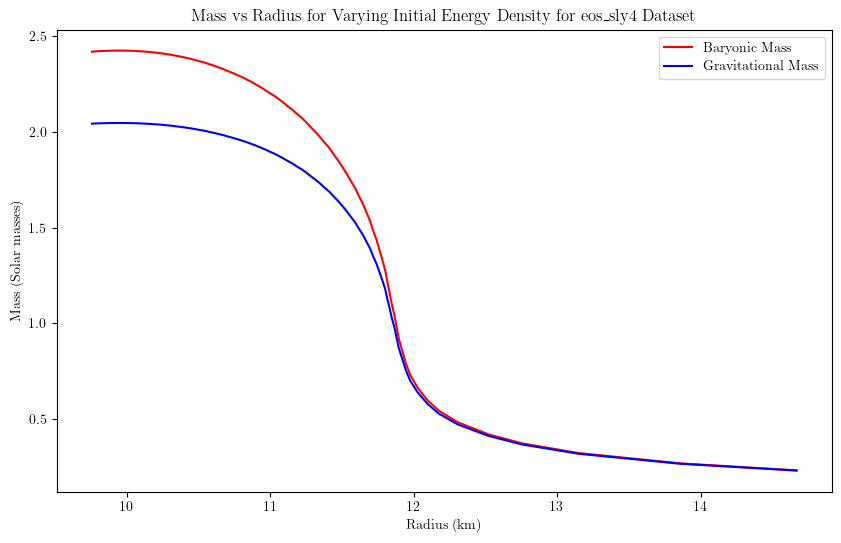

In [10]:
Solar_mass_in_km = 1.47662504
Epsilon0 = 58.68e-5  # Geometric Unit
Rho0 = 58.68e-5
Radius0 = 0.1  # Geometric Unit
Mass0 = (4 / 3) * (mth.pi) * (Radius0 ** 3) * Epsilon0  # Geometric Unit
Pressure0 = Pressure_function(Epsilon0)
h = 0.005
Pressure_Limit = 10 ** (-14)
MassB0 = Mb0(Mass0, Epsilon0, Radius0)

# Lists to store final results
final_masses_s = []
final_radii_s = []
final_massb_s = []


Epsilon0_s = np.linspace(0.4, 4, 100) * 58.68e-5
Pressure0_s = np.array([Pressure_function(i) for i in Epsilon0_s])
Rho0_s = np.array([Rho_function(i) for i in Pressure0_s])

for n in Epsilon0_s:
    
    
    Epsilon0 = n                                          # Geometric Unit
    Pressure0 = Pressure_function(Epsilon0)
    Rho0 = Rho_function(Pressure0)
    Radius0 = 0.01                                        # Geometric Unit
    Mass0 = (4 / 3) * mth.pi * (Radius0 ** 3) * Epsilon0  # Geometric Unit
    h = 0.005
    Pressure_Limit = 10 ** (-14)
    MassB0 = Mb0(Rho0, Mass0, Radius0)


    MassB = [MassB0]
    Mass = [Mass0]
    Pressure = [Pressure0]
    Epsilon = [Epsilon0]
    Radius = [Radius0]
    Rho = [Rho0]

    
    while Pressure[-1] > Pressure_Limit:
        Coefficient = RK4_Slope(Mass[-1], MassB[-1], Pressure[-1], Epsilon[-1], Rho[-1], Radius[-1], h)
        Mass_i = Mass[-1] + h * Coefficient[0]
        MassB_i = MassB[-1] + h * Coefficient[1]
        Pressure_i = Pressure[-1] + h * Coefficient[2]
        Epsilon_i = Energy_Density_function(Pressure_i)
        Rho_i = Rho_function(Pressure_i)
        Radius_i = Radius[-1] + h

        MassB.append(MassB_i)
        Mass.append(Mass_i)
        Pressure.append(Pressure_i)
        Epsilon.append(Epsilon_i)
        Radius.append(Radius_i)
        Rho.append(Rho_i)

    final_massb_s.append(MassB[-1] / Solar_mass_in_km)
    final_masses_s.append(Mass[-1] / Solar_mass_in_km)
    final_radii_s.append(Radius[-1])


plt.figure(figsize=(10, 6))
plt.plot(final_radii_s, final_massb_s, 'r-', label='Baryonic Mass')
plt.plot(final_radii_s, final_masses_s, 'b-', label='Gravitational Mass')
plt.xlabel('Radius (km)')
plt.ylabel('Mass (Solar masses)')
plt.title('Mass vs Radius for Varying Initial Energy Density for eos_sly4 Dataset')
plt.legend()
plt.show()

In [11]:
# MR_sly4 = []
# for i in range(0,len(final_radii_s)):
#     Array_s = [Epsilon0_s[i], Rho0_s[i], Pressure0_s[i], final_masses_s[i], final_massb_s[i], final_radii_s[i]]
#     MR_sly4.append(Array_s)
# MR_sly4 = np.array(MR_sly4)
# np.savetxt('MR_sly4_Geometric ', MR_sly4, delimiter = '\t', header = 'Epsilon0    Rho0    Pressure0    Gravitational Mass (Solar Masses)    Baryonic Mass (Solar Masses)    Radius' )

/tmp/ipykernel_16342/743171533.py:8: RuntimeWarning: invalid value encountered in scalar power
  return (Pressure/K) ** (1/Gamma)


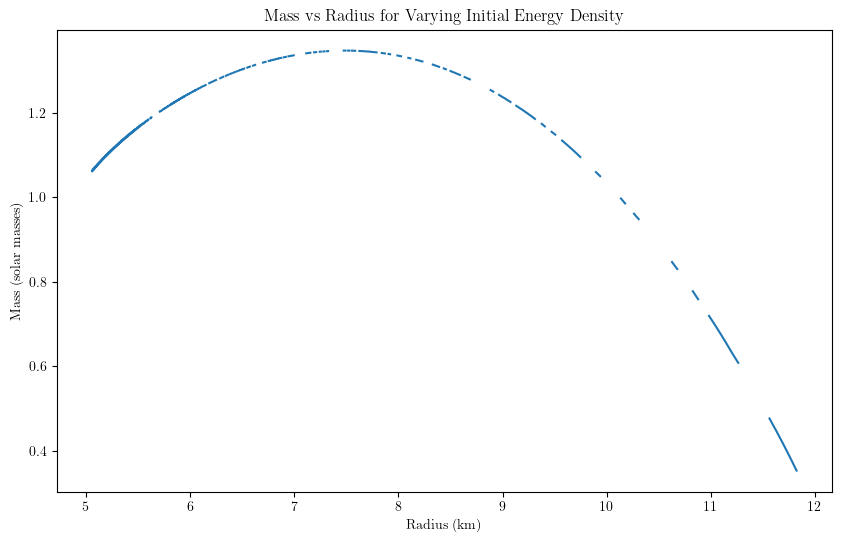

In [12]:
# G = 1
# c = 1
Solar_mass_in_km = 1.47662504

def Energy_Density_function(Pressure):
    K = 100
    Gamma = 2
    return (Pressure/K) ** (1/Gamma)

def Pressure_function(Epsilon):
    K = 100
    Gamma = 2
    return K*((Epsilon)**(Gamma))

def dmdr(Epsilon, Radius):
    return 4*mth.pi*Epsilon*(Radius**2)

def dpdr(Epsilon, Pressure, Mass, Radius):
    return (-(Epsilon + Pressure )*(Mass + ((4*mth.pi*(Radius**3))*Pressure)))/(Radius*(Radius-(2*Mass)))

Epsilon0 = 6*58.68e-5                        # Geometric Unit
Radius0 = 0.1                                # Geometric Unit
Mass0 = (4/3)*(mth.pi)*(Radius0**3)*Epsilon0 # Geometric Unit
Pressure0 = Pressure_function(Epsilon0)
h = 0.005
Pressure_Limit = 10**(-14)


def RK4_Slope(Mass, Epsilon, Pressure, Radius, h):
    
    k_Mass_1     = dmdr(Epsilon, Radius)
    k_Pressure_1 = dpdr(Epsilon, Pressure, Mass, Radius)
    k_Epsilon_1  = Energy_Density_function(Pressure)
   
    k_Mass_2     = dmdr(Epsilon + 0.5 * h * k_Epsilon_1, Radius + 0.5 * h)
    k_Pressure_2 = dpdr(Epsilon + 0.5 * h * k_Epsilon_1, Pressure + 0.5 * h * k_Pressure_1, Mass + 0.5 * h * k_Mass_1, Radius + 0.5 * h)
    k_Epsilon_2  = Energy_Density_function(Pressure + 0.5 * h * k_Pressure_1)
    
    k_Mass_3     = dmdr(Epsilon + 0.5 * h * k_Epsilon_2, Radius + 0.5 * h)
    k_Pressure_3 = dpdr(Epsilon + 0.5 * h * k_Epsilon_2, Pressure + 0.5 * h * k_Pressure_2, Mass + 0.5 * h * k_Mass_2, Radius + 0.5 * h)
    k_Epsilon_3  = Energy_Density_function(Pressure + 0.5 * h * k_Pressure_2)
    
    k_Mass_4     = dmdr(Epsilon + h * k_Epsilon_3, Radius + h)
    k_Pressure_4 = dpdr(Epsilon + h * k_Epsilon_3, Pressure + h * k_Pressure_3, Mass + h * k_Mass_3, Radius + h)
    k_Epsilon_4  = Energy_Density_function(Pressure + h * k_Pressure_3)
    
    return [(1/6)*(k_Mass_1+(2*k_Mass_2)+(2*k_Mass_3)+k_Mass_4), (1/6)*(k_Epsilon_1+(2*k_Epsilon_2)+(2*k_Epsilon_3)+k_Epsilon_4), (1/6)*(k_Pressure_1+(2*k_Pressure_2)+(2*k_Pressure_3)+k_Pressure_4)]



final_masses_pol = []
final_radii_pol = []

multipliers = np.linspace(0.3, 50, 1000)

for n in multipliers:
    Epsilon0 = 0.000549724985 * n
    Mass0 = (4 / 3) * mth.pi * (Radius0 ** 3) * Epsilon0
    Pressure0 = Pressure_function(Epsilon0)
    
    Mass = [Mass0]
    Pressure = [Pressure0]
    Epsilon = [Epsilon0]
    Radius = [Radius0]
    
    while Pressure[-1] > Pressure_Limit:
        Coefficient = RK4_Slope(Mass[-1], Epsilon[-1], Pressure[-1], Radius[-1], h)
        Mass_i = Mass[-1] + Coefficient[0] * h
        Pressure_i = Pressure[-1] + Coefficient[2] * h
        Epsilon_i = Energy_Density_function(Pressure_i)
        Radius_i = Radius[-1] + h
        
        Mass.append(Mass_i)
        Pressure.append(Pressure_i)
        Epsilon.append(Epsilon_i)
        Radius.append(Radius_i)
    
    final_masses_pol.append(Mass[-1] / Solar_mass_in_km)
    final_radii_pol.append(Radius[-1])

plt.figure(figsize=(10, 6))
plt.plot(final_radii_pol, final_masses_pol)
plt.xlabel('Radius (km)')
plt.ylabel('Mass (solar masses)')
plt.title('Mass vs Radius for Varying Initial Energy Density')
plt.show()


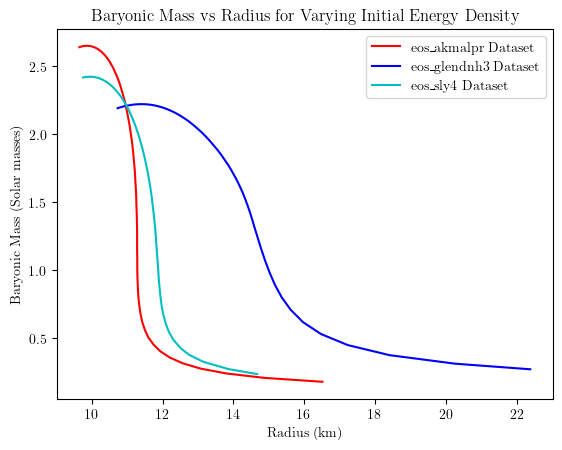

In [13]:
plt.plot(final_radii_a, final_massb_a, 'r-', label='eos_akmalpr Dataset')
plt.plot(final_radii_g, final_massb_g, 'b-', label='eos_glendnh3 Dataset')
plt.plot(final_radii_s, final_massb_s, 'c-', label='eos_sly4 Dataset')
plt.xlabel('Radius (km)')
plt.ylabel('Baryonic Mass (Solar masses)')
plt.title('Baryonic Mass vs Radius for Varying Initial Energy Density')
# plt.savefig('Baryonic Mass vs Radius for Varying Initial Energy Density')
plt.legend()
plt.show()

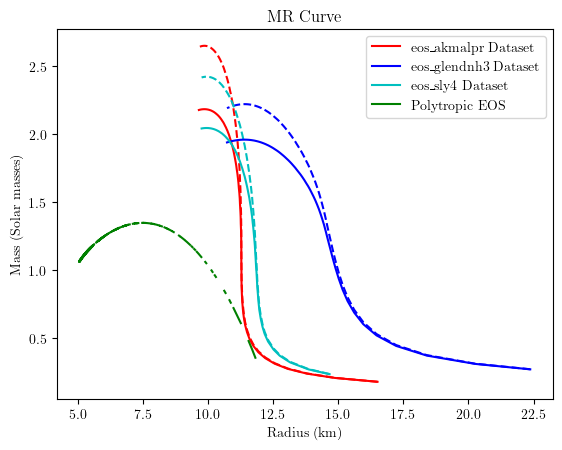

In [14]:
plt.plot(final_radii_a, final_massb_a, 'r', linestyle='dashed')
plt.plot(final_radii_g, final_massb_g, 'b', linestyle='dashed')
plt.plot(final_radii_s, final_massb_s, 'c', linestyle='dashed')
plt.plot(final_radii_a, final_masses_a, 'r-', label='eos_akmalpr Dataset')
plt.plot(final_radii_g, final_masses_g, 'b-', label='eos_glendnh3 Dataset')
plt.plot(final_radii_s, final_masses_s, 'c-', label='eos_sly4 Dataset')
plt.plot(final_radii_pol, final_masses_pol, 'g-', label='Polytropic EOS')
plt.xlabel('Radius (km)')
plt.ylabel('Mass (Solar masses)')
plt.title('MR Curve')
# plt.savefig('MR Curve')
plt.legend()
plt.show()

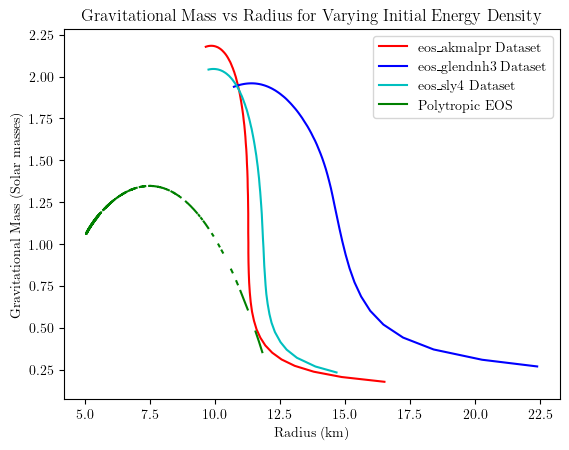

In [15]:
plt.plot(final_radii_a, final_masses_a, 'r-', label='eos_akmalpr Dataset')
plt.plot(final_radii_g, final_masses_g, 'b-', label='eos_glendnh3 Dataset')
plt.plot(final_radii_s, final_masses_s, 'c-', label='eos_sly4 Dataset')
plt.plot(final_radii_pol, final_masses_pol, 'g-', label='Polytropic EOS')
plt.xlabel('Radius (km)')
plt.ylabel('Gravitational Mass (Solar masses)')
plt.title('Gravitational Mass vs Radius for Varying Initial Energy Density')
# plt.savefig('Gravitational Mass vs Radius for Varying Initial Energy Density')
plt.legend()
plt.show()

# Piece wise Polytrop

In [16]:
file_path = 'ghost_eos.d'
Gamma_array = np.loadtxt(file_path, skiprows = 2, usecols = 0, max_rows = 7)
K0 = 6.8011 *10 **(-9)
LogRho = np.loadtxt(file_path, skiprows = 12, usecols = 0, max_rows = 6)
Rho_array = np.array([10**i for i in LogRho])  #in g cm-3


K = [K0] # K for cgs outputs
for i in range(1,len(Rho_array)+1):
    Ki = K[i-1]*((Rho_array[i-1])**(Gamma_array[i-1]-Gamma_array[i]))
    K.append(Ki)
    
for i in range(0,len(K)):
    K[i] *= (7.4237e-19)**(1-Gamma_array[i]) #for geometric outputs
    
Rho_array = Rho_array*(7.4237e-19) #in km-2

def dmdr(Epsilon, Radius):
    return 4 * mth.pi * Epsilon * (Radius ** 2)

def dpdr(Epsilon, Pressure, Mass, Radius):
    return (-(Epsilon + Pressure) * (Mass + (4 * mth.pi * (Radius ** 3) * Pressure))) / (Radius * (Radius - (2 * Mass)))

def dMdr(Rho, Mass, Radius):
    return 4 * mth.pi * Rho * (Radius ** 2) * ((1 - 2 * Mass / Radius) ** (-1 / 2))

def Mb0(rho0, m0, r0):
    M = [m0]
    r = r0
    i = 0
    h = 0.005  # Step size
    while r <= r0:
        K_Mass_B_1 = dMdr(rho0, m0, r)
        K_Mass_B_2 = dMdr(rho0, m0, r + 0.5 * h)
        K_Mass_B_3 = dMdr(rho0, m0, r + 0.5 * h)
        K_Mass_B_4 = dMdr(rho0, m0, r + h)
        m = M[i] + ((1 / 6) * (K_Mass_B_1 + 2 * K_Mass_B_2 + 2 * K_Mass_B_3 + K_Mass_B_4))
        M.append(m)
        r += h
        i += 1
    return M[-1]

def Pressure_function(Rho): #in km-2
    for i in range(len(Rho_array) - 1): 
        if Rho>0 and Rho<=Rho_array[0]:
            return K[0] * (Rho ** Gamma_array[0])
        elif Rho_array[i] < Rho <= Rho_array[i + 1]:
            return K[i+1] * (Rho ** Gamma_array[i+1])
        elif Rho > Rho_array[-1]:
            return K[-1] * (Rho ** Gamma_array[-1])

Pressure_array = np.array([Pressure_function(i) for i in Rho_array])

def Rho_function(Pressure): #in km-2
    for i in range(len(Pressure_array)-1):
        if Pressure <=Pressure_array[0]:
            return (Pressure/K[0])**(1/Gamma_array[0])        
        elif Pressure_array[i] < Pressure <=Pressure_array[i+1]:
            return (Pressure/K[i+1])**(1/Gamma_array[i+1])
        elif Pressure > Pressure_array[-1]:
            return (Pressure/K[-1])**(1/Gamma_array[-1])
        
A_array = [0] #ai

for i in range(1,len(K)):
    ai = A_array[i-1] + ((Pressure_array[i-1]/Rho_array[i-1])*((1/(Gamma_array[i-1]-1))-(1/(Gamma_array[i]-1))))
    A_array.append(ai)

def Energy_Density_function(Pressure):
    for i in range(len(Pressure_array)-1):
        if Pressure <= Pressure_array[0]:
            return ((1+A_array[0]) * Rho_function(Pressure)+((K[0]*(Rho_function(Pressure)**(Gamma_array[0]))))/(Gamma_array[0]-1))
        elif Pressure_array[i] < Pressure <= Pressure_array[i+1]:
            return ((1+A_array[i+1])*Rho_function(Pressure))+((K[i+1]*(Rho_function(Pressure)**(Gamma_array[i+1])))/(Gamma_array[i+1]-1))
        elif Pressure >= Pressure_array[-1]:
            return ((1+A_array[-1])*Rho_function(Pressure))+((K[-1]*(Rho_function(Pressure)**(Gamma_array[-1])))/(Gamma_array[-1]-1))
    

def RK4_Slope(Mass, MassB, Pressure, Epsilon, Rho, Radius, h):
    k_Mass_1 = dmdr(Epsilon, Radius)
    k_Mass_B_1 = dMdr(Rho, Mass, Radius)
    k_Pressure_1 = dpdr(Epsilon, Pressure, Mass, Radius)
    k_Epsilon_1 = Energy_Density_function(Pressure)
    k_Rho_1 = Rho_function(Pressure)

    k_Mass_2 = dmdr(Epsilon + 0.5 * h * k_Epsilon_1, Radius + 0.5 * h)
    k_Mass_B_2 = dMdr(Rho + 0.5 * h * k_Rho_1, Mass + 0.5 * h * k_Mass_1, Radius + 0.5 * h)
    k_Pressure_2 = dpdr(Epsilon + 0.5 * h * k_Epsilon_1, Pressure + 0.5 * h * k_Pressure_1, Mass + 0.5 * h * k_Mass_1, Radius + 0.5 * h)
    k_Epsilon_2 = Energy_Density_function(Pressure + 0.5 * h * k_Pressure_1)
    k_Rho_2 = Rho_function(Pressure + 0.5 * h * k_Pressure_1)

    k_Mass_3 = dmdr(Epsilon + 0.5 * h * k_Epsilon_2, Radius + 0.5 * h)
    k_Mass_B_3 = dMdr(Rho + 0.5 * h * k_Rho_2, Mass + 0.5 * h * k_Mass_2, Radius + 0.5 * h)
    k_Pressure_3 = dpdr(Epsilon + 0.5 * h * k_Epsilon_2, Pressure + 0.5 * h * k_Pressure_2, Mass + 0.5 * h * k_Mass_2, Radius + 0.5 * h)
    k_Epsilon_3 = Energy_Density_function(Pressure + 0.5 * h * k_Pressure_2)
    k_Rho_3 = Rho_function(Pressure + 0.5 * h * k_Pressure_2)

    k_Mass_4 = dmdr(Epsilon + h * k_Epsilon_3, Radius + h)
    k_Mass_B_4 = dMdr(Rho + h * k_Rho_3, Mass + h * k_Mass_3, Radius + h)
    k_Pressure_4 = dpdr(Epsilon + h * k_Epsilon_3, Pressure + h * k_Pressure_3, Mass + h * k_Mass_3, Radius + h)
    k_Epsilon_4 = Energy_Density_function(Pressure + h * k_Pressure_3)
    k_Rho_4 = Rho_function(Pressure + h * k_Pressure_3)

    return [(1 / 6) * (k_Mass_1 + 2 * k_Mass_2 + 2 * k_Mass_3 + k_Mass_4),
            (1 / 6) * (k_Mass_B_1 + 2 * k_Mass_B_2 + 2 * k_Mass_B_3 + k_Mass_B_4),
            (1 / 6) * (k_Pressure_1 + 2 * k_Pressure_2 + 2 * k_Pressure_3 + k_Pressure_4),
           ]

print(f'Pressure points: {Pressure_array}')
print(f'Rest Mass Density in Geometric Unit: {Rho_array}')
print(f'Values of K: {K}')
print(f'Values of Gamma: {Gamma_array}')
print(f'Values of A: {A_array}')

Pressure points: [2.55179892e-15 6.32811089e-10 2.11351372e-09 4.93597828e-07
 2.00008402e-05 1.57560823e-04]
Rest Mass Density in Geometric Unit: [1.81184238e-11 2.80879739e-07 1.95083444e-06 1.08547647e-04
 3.72066367e-04 7.42370000e-04]
Values of K: [265.86990727912604, 0.17186612974871013, 7.547467021415085e-06, 0.11822768577357896, 403955.8463963463, 353211.18277538754, 131616.2284463675]
Values of Gamma: [1.58425 1.28733 0.62223 1.35692 3.005   2.988   2.851  ]
Values of A: [0, -0.000249106920820342, 0.013555758473555312, 0.007652518519789675, 0.018124909654793325, 0.01789564030944299, 0.009993848284230071]


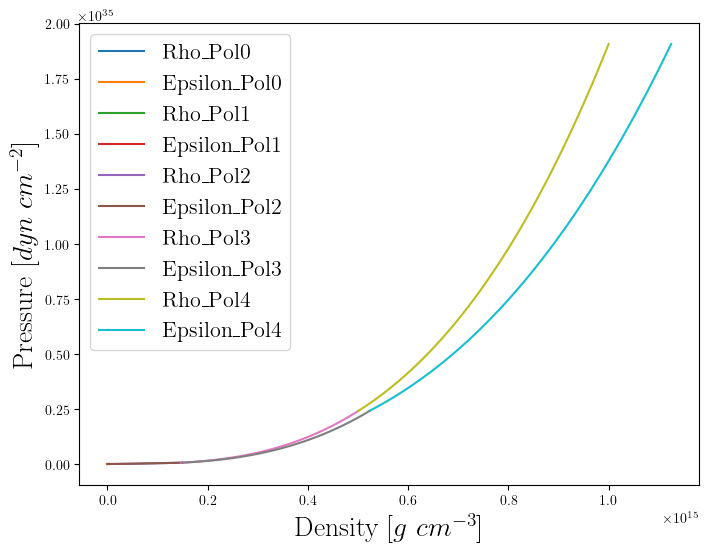

In [17]:
arrs = []
ep_gh = [Energy_Density_function(i) for i in Pressure_array]
ep_arrs = []
for s in range(1,len(Rho_array)):
    a = np.linspace(Rho_array[s-1], Rho_array[s])
    b = np.linspace(ep_gh[s-1], ep_gh[s])
    arrs.append(a)
    ep_arrs.append(b)
ps = []

for t in range(0,len(arrs)):
    P = []
    for v in arrs[t]:
        P.append(K[t+1]*(v**Gamma_array[t+1]))
    ps.append(P)
plt.figure(figsize=(8, 6))
for w in range(0, len(arrs)):
    arrs_np = np.array(arrs[w])
    ep_arrs_np = np.array(ep_arrs[w])
    ps_np = np.array(ps[w])
    plt.plot(arrs_np / (7.4237 * 1e-19), ps_np / (8.2601 * 1e-40), label=f'Rho_Pol{w}')
    plt.plot(ep_arrs_np / (7.4237 * 1e-19), ps_np / (8.2601 * 1e-40), label=f'Epsilon_Pol{w}')


plt.ylabel('Pressure [$dyn\ cm^{-2}$]', fontsize=20)
plt.xlabel('Density  [$ g\ cm^{-3} $]', fontsize=20)
# plt.title('Piece-Wise Polytrop for Dataset 1')
plt.legend(fontsize=16)
plt.savefig('Piece-wise_1.pdf', format='pdf',bbox_inches="tight")
plt.show()


Baryonic Mass of star: 1.3090508332561266 Solar masses
Mass of star: 1.2053343563734484 Solar masses
Radius of star: 11.70500000000043 km


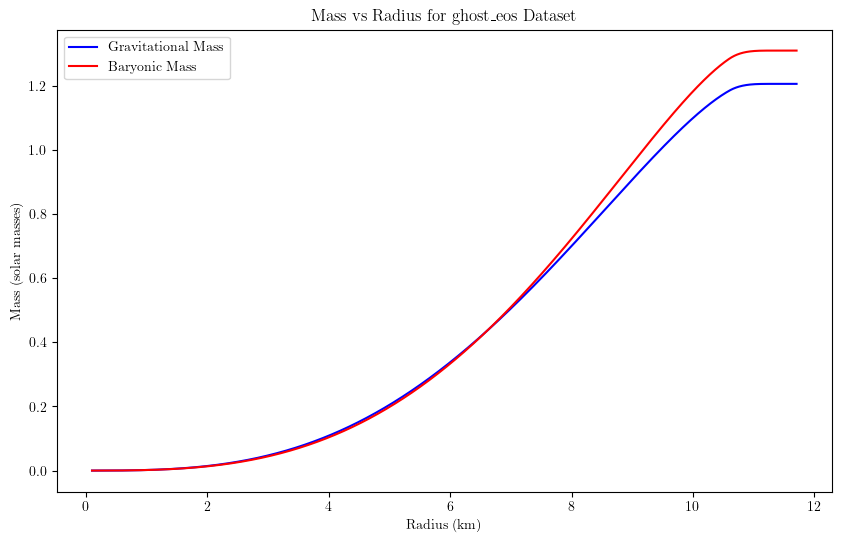

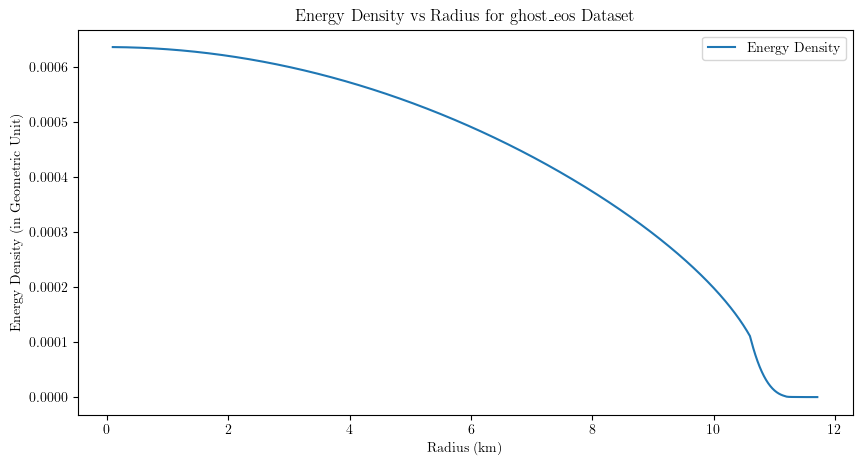

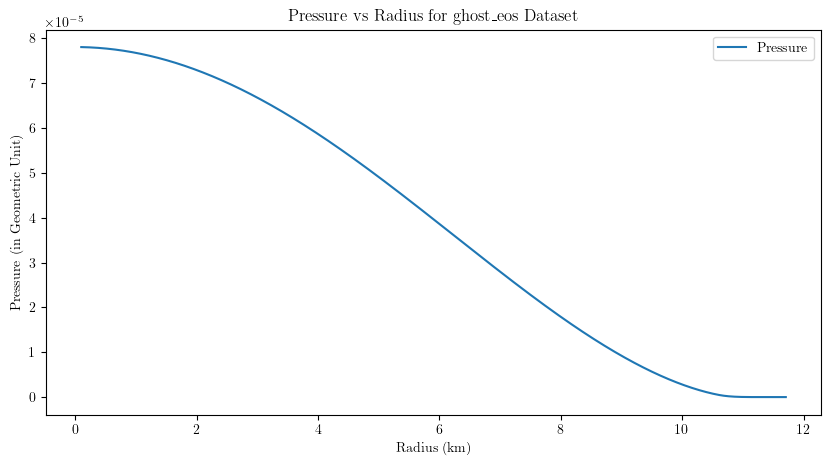

In [18]:
Solar_mass_in_km = 1.47662504
Rho0 = 58.68e-5
Pressure0 = Pressure_function(Rho0)
Epsilon0 = Energy_Density_function(Pressure0)
Radius0 = 0.1                                         # Geometric Unit
Mass0 = (4 / 3) * mth.pi * (Radius0 ** 3) * Epsilon0  # Geometric Unit
h = 0.005
Pressure_Limit = 10 ** (-14)
MassB0 = Mb0(Rho0, Mass0, Radius0)  

MassB = [MassB0]
Mass = [Mass0]
Pressure = [Pressure0]
Epsilon = [Epsilon0]
Radius = [Radius0]
Rho = [Rho0]

# RK4 integration
while Pressure[-1] > Pressure_Limit:
    Coefficient = RK4_Slope(Mass[-1], MassB[-1], Pressure[-1], Epsilon[-1], Rho[-1], Radius[-1], h)
    Mass_i = Mass[-1] + h * Coefficient[0]
    MassB_i = MassB[-1] + h * Coefficient[1]
    Pressure_i = Pressure[-1] + h * Coefficient[2]
    Rho_i = Rho_function(Pressure_i)
    Epsilon_i = Energy_Density_function(Pressure_i)
    Radius_i = Radius[-1] + h

    MassB.append(MassB_i)
    Mass.append(Mass_i)
    Pressure.append(Pressure_i)
    Epsilon.append(Epsilon_i)
    Radius.append(Radius_i)
    Rho.append(Rho_i)

# Final results
MassB_star = MassB[-1]
Mass_star = Mass[-1]
Radius_star = Radius[-1]

print(f'Baryonic Mass of star: {MassB_star / Solar_mass_in_km} Solar masses')
print(f'Mass of star: {Mass_star / Solar_mass_in_km} Solar masses')
print(f'Radius of star: {Radius_star} km')

# Plotting results
Mass_1 = np.array(Mass)
Mass_2 = np.array(MassB)

plt.figure(figsize=(10, 6))
plt.plot(Radius, Mass_1 / Solar_mass_in_km, 'b-', label='Gravitational Mass')
plt.plot(Radius, Mass_2 / Solar_mass_in_km, 'r-', label='Baryonic Mass')
plt.xlabel('Radius (km)')
plt.ylabel('Mass (solar masses)')
plt.title('Mass vs Radius for ghost_eos Dataset')
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(Radius, Epsilon, label='Energy Density')
plt.xlabel('Radius (km)')
plt.ylabel('Energy Density (in Geometric Unit)')
plt.title('Energy Density vs Radius for ghost_eos Dataset')
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(Radius, Pressure, label='Pressure')
plt.xlabel('Radius (km)')
plt.ylabel('Pressure (in Geometric Unit)')
plt.title('Pressure vs Radius for ghost_eos Dataset')
plt.legend()
plt.show()

/tmp/ipykernel_16342/1122669701.py:57: RuntimeWarning: invalid value encountered in scalar power
  return (Pressure/K[0])**(1/Gamma_array[0])


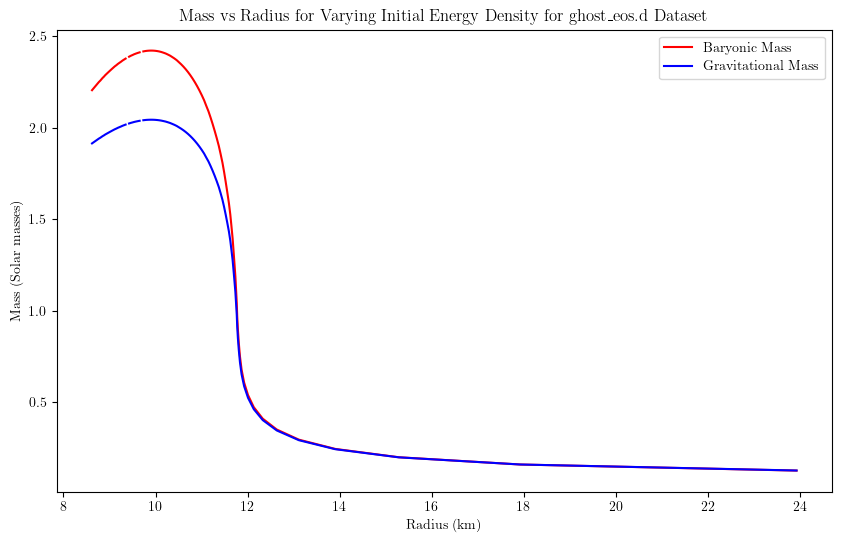

In [19]:
final_masses_ghost1 = []
final_radii_ghost1 = []
final_massb_ghost1 = []


Rho0_ghost1 = np.linspace(0.3, 4, 100) * 58.68e-5
Pressure0_ghost1 = np.array([Pressure_function(i) for i in Rho0_ghost1])
Epsilon0_ghost1 = np.array([Energy_Density_function(i) for i in Pressure0_ghost1])


for n in Rho0_ghost1:
    
    Rho0 = n
    Pressure0 = Pressure_function(Rho0)
    Epsilon0 = Energy_Density_function(Pressure0)
    Radius0 = 0.1                                         # Geometric Unit
    Mass0 = (4 / 3) * mth.pi * (Radius0 ** 3) * Epsilon0  # Geometric Unit
    h = 0.005
    Pressure_Limit = 10 ** (-14)
    MassB0 = Mb0(Rho0, Mass0, Radius0)  


    MassB = [MassB0]
    Mass = [Mass0]
    Pressure = [Pressure0]
    Epsilon = [Epsilon0]
    Radius = [Radius0]
    Rho = [Rho0]

    
    while Pressure[-1] > Pressure_Limit:
        Coefficient = RK4_Slope(Mass[-1], MassB[-1], Pressure[-1], Epsilon[-1], Rho[-1], Radius[-1], h)
        Mass_i = Mass[-1] + h * Coefficient[0]
        MassB_i = MassB[-1] + h * Coefficient[1]
        Pressure_i = Pressure[-1] + h * Coefficient[2]
        Epsilon_i = Energy_Density_function(Pressure_i)
        Rho_i = Rho_function(Pressure_i)
        Radius_i = Radius[-1] + h

        MassB.append(MassB_i)
        Mass.append(Mass_i)
        Pressure.append(Pressure_i)
        Epsilon.append(Epsilon_i)
        Radius.append(Radius_i)
        Rho.append(Rho_i)

    final_massb_ghost1.append(MassB[-1] / Solar_mass_in_km)
    final_masses_ghost1.append(Mass[-1] / Solar_mass_in_km)
    final_radii_ghost1.append(Radius[-1])


plt.figure(figsize=(10, 6))
plt.plot(final_radii_ghost1, final_massb_ghost1, 'r-', label='Baryonic Mass')
plt.plot(final_radii_ghost1, final_masses_ghost1, 'b-', label='Gravitational Mass')
plt.xlabel('Radius (km)')
plt.ylabel('Mass (Solar masses)')
plt.title('Mass vs Radius for Varying Initial Energy Density for ghost_eos.d Dataset')
plt.legend()
plt.show()

In [20]:
# MR_ghost1 = []
# for i in range(0,len(final_radii_ghost1)):
#     Array_ghost1 = [Epsilon0_ghost1[i], Rho0_ghost1[i], Pressure0_ghost1[i], final_masses_ghost1[i], final_massb_ghost1[i], final_radii_ghost1[i]]
#     MR_ghost1.append(Array_ghost1)
# MR_ghost1 = np.array(MR_ghost1)
# np.savetxt('MR_ghost1_Geometric ', MR_ghost1, delimiter = '\t', header = 'Epsilon0    Rho0    Pressure0    Gravitational Mass (Solar Masses)    Baryonic Mass (Solar Masses)    Radius' )

In [21]:
file_path = 'ghost_r5_eos.d'
Gamma_array = np.loadtxt(file_path, skiprows = 2, usecols = 0, max_rows = 9)
K0 = 6.8011 *10 **(-9)
LogRho = np.loadtxt(file_path, skiprows = 14, usecols = 0, max_rows = 8)
Rho_array = np.array([10**i for i in LogRho])  #in g cm-3


K = [K0] # K for cgs outputs
for i in range(1,len(Rho_array)+1):
    Ki = K[i-1]*((Rho_array[i-1])**(Gamma_array[i-1]-Gamma_array[i]))
    K.append(Ki)
    
for i in range(0,len(K)):
    K[i] *= (7.4237e-19)**(1-Gamma_array[i]) #for geometric outputs
    
Rho_array = Rho_array*(7.4237e-19) #in km-2

def dmdr(Epsilon, Radius):
    return 4 * mth.pi * Epsilon * (Radius ** 2)

def dpdr(Epsilon, Pressure, Mass, Radius):
    return (-(Epsilon + Pressure) * (Mass + (4 * mth.pi * (Radius ** 3) * Pressure))) / (Radius * (Radius - (2 * Mass)))

def dMdr(Rho, Mass, Radius):
    return 4 * mth.pi * Rho * (Radius ** 2) * ((1 - 2 * Mass / Radius) ** (-1 / 2))

def Mb0(rho0, m0, r0):
    M = [m0]
    r = r0
    i = 0
    h = 0.005  # Step size
    while r <= r0:
        K_Mass_B_1 = dMdr(rho0, m0, r)
        K_Mass_B_2 = dMdr(rho0, m0, r + 0.5 * h)
        K_Mass_B_3 = dMdr(rho0, m0, r + 0.5 * h)
        K_Mass_B_4 = dMdr(rho0, m0, r + h)
        m = M[i] + ((1 / 6) * (K_Mass_B_1 + 2 * K_Mass_B_2 + 2 * K_Mass_B_3 + K_Mass_B_4))
        M.append(m)
        r += h
        i += 1
    return M[-1]

def Pressure_function(Rho): #in km-2
    for i in range(len(Rho_array) - 1): 
        if Rho>0 and Rho<=Rho_array[0]:
            return K[0] * (Rho ** Gamma_array[0])
        elif Rho_array[i] < Rho <= Rho_array[i + 1]:
            return K[i+1] * (Rho ** Gamma_array[i+1])
        elif Rho > Rho_array[-1]:
            return K[-1] * (Rho ** Gamma_array[-1])

Pressure_array = np.array([Pressure_function(i) for i in Rho_array])

def Rho_function(Pressure): #in km-2
    for i in range(len(Pressure_array)-1):
        if Pressure <=Pressure_array[0]:
            return (Pressure/K[0])**(1/Gamma_array[0])        
        elif Pressure_array[i] < Pressure <=Pressure_array[i+1]:
            return (Pressure/K[i+1])**(1/Gamma_array[i+1])
        elif Pressure > Pressure_array[-1]:
            return (Pressure/K[-1])**(1/Gamma_array[-1])
        
A_array = [0] #ai

for i in range(1,len(K)):
    ai = A_array[i-1] + ((Pressure_array[i-1]/Rho_array[i-1])*((1/(Gamma_array[i-1]-1))-(1/(Gamma_array[i]-1))))
    A_array.append(ai)

def Energy_Density_function(Pressure):
    for i in range(len(Pressure_array)-1):
        if Pressure <= Pressure_array[0]:
            return ((1+A_array[0]) * Rho_function(Pressure)+((K[0]*(Rho_function(Pressure)**(Gamma_array[0]))))/(Gamma_array[0]-1))
        elif Pressure_array[i] < Pressure <= Pressure_array[i+1]:
            return ((1+A_array[i+1])*Rho_function(Pressure))+((K[i+1]*(Rho_function(Pressure)**(Gamma_array[i+1])))/(Gamma_array[i+1]-1))
        elif Pressure > Pressure_array[-1]:
            return ((1+A_array[-1])*Rho_function(Pressure))+((K[-1]*(Rho_function(Pressure)**(Gamma_array[-1])))/(Gamma_array[-1]-1))
    

def RK4_Slope(Mass, MassB, Pressure, Epsilon, Rho, Radius, h):
    k_Mass_1 = dmdr(Epsilon, Radius)
    k_Mass_B_1 = dMdr(Rho, Mass, Radius)
    k_Pressure_1 = dpdr(Epsilon, Pressure, Mass, Radius)
    k_Epsilon_1 = Energy_Density_function(Pressure)
    k_Rho_1 = Rho_function(Pressure)

    k_Mass_2 = dmdr(Epsilon + 0.5 * h * k_Epsilon_1, Radius + 0.5 * h)
    k_Mass_B_2 = dMdr(Rho + 0.5 * h * k_Rho_1, Mass + 0.5 * h * k_Mass_1, Radius + 0.5 * h)
    k_Pressure_2 = dpdr(Epsilon + 0.5 * h * k_Epsilon_1, Pressure + 0.5 * h * k_Pressure_1, Mass + 0.5 * h * k_Mass_1, Radius + 0.5 * h)
    k_Epsilon_2 = Energy_Density_function(Pressure + 0.5 * h * k_Pressure_1)
    k_Rho_2 = Rho_function(Pressure + 0.5 * h * k_Pressure_1)

    k_Mass_3 = dmdr(Epsilon + 0.5 * h * k_Epsilon_2, Radius + 0.5 * h)
    k_Mass_B_3 = dMdr(Rho + 0.5 * h * k_Rho_2, Mass + 0.5 * h * k_Mass_2, Radius + 0.5 * h)
    k_Pressure_3 = dpdr(Epsilon + 0.5 * h * k_Epsilon_2, Pressure + 0.5 * h * k_Pressure_2, Mass + 0.5 * h * k_Mass_2, Radius + 0.5 * h)
    k_Epsilon_3 = Energy_Density_function(Pressure + 0.5 * h * k_Pressure_2)
    k_Rho_3 = Rho_function(Pressure + 0.5 * h * k_Pressure_2)

    k_Mass_4 = dmdr(Epsilon + h * k_Epsilon_3, Radius + h)
    k_Mass_B_4 = dMdr(Rho + h * k_Rho_3, Mass + h * k_Mass_3, Radius + h)
    k_Pressure_4 = dpdr(Epsilon + h * k_Epsilon_3, Pressure + h * k_Pressure_3, Mass + h * k_Mass_3, Radius + h)
    k_Epsilon_4 = Energy_Density_function(Pressure + h * k_Pressure_3)
    k_Rho_4 = Rho_function(Pressure + h * k_Pressure_3)

    return [(1 / 6) * (k_Mass_1 + 2 * k_Mass_2 + 2 * k_Mass_3 + k_Mass_4),
            (1 / 6) * (k_Mass_B_1 + 2 * k_Mass_B_2 + 2 * k_Mass_B_3 + k_Mass_B_4),
            (1 / 6) * (k_Pressure_1 + 2 * k_Pressure_2 + 2 * k_Pressure_3 + k_Pressure_4),
           ]

print(f'Pressure points: {Pressure_array}')
print(f'Rest Mass Density in Geometric Unit: {Rho_array}')
print(f'Values of K: {K}')
print(f'Values of Gamma: {Gamma_array}')
print(f'Values of A: {A_array}')

Pressure points: [2.53423166e-15 6.31228076e-10 2.11053544e-09 3.45078640e-07
 3.79305113e-05 4.74798363e-05 1.73375828e-04 8.80412603e-04]
Rest Mass Density in Geometric Unit: [1.80395910e-11 2.80615860e-07 1.95243310e-06 8.35339027e-05
 3.84987352e-04 7.42370000e-04 8.69391629e-04 1.16207164e-03]
Values of K: [265.86990727912604, 0.1716437570024778, 7.532990936174701e-06, 0.11792993104977989, 1206632.1900944654, 0.0005580312802945671, 2.1748125198895887e+21, 23954218430750.566, 0.01313993117819414]
Values of Gamma: [1.58425    1.28733    0.62223    1.35692    3.07583    0.34196853
 8.2        5.6        0.4       ]
Values of A: [0, -0.0002484731031396745, 0.013534807667054633, 0.0076447131154282425, 0.017228690383717625, 0.21441660324735984, 0.10833907246356873, 0.09268396278228921, 1.5200902703917603]


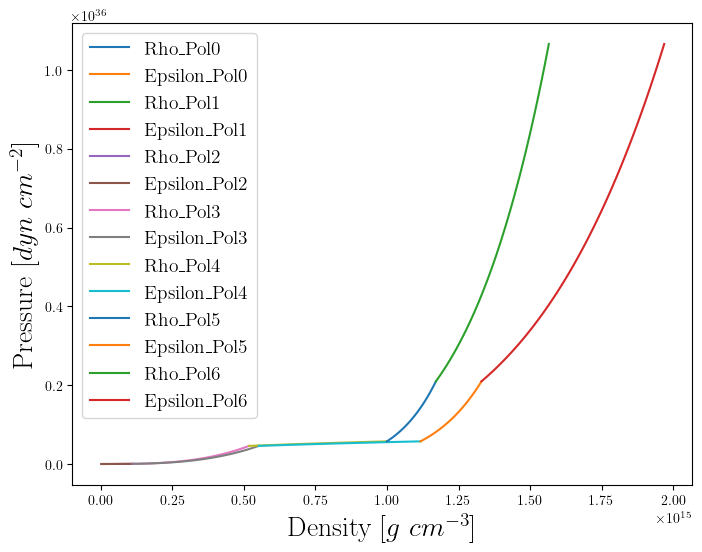

In [22]:
arrs = []
ep_gh = [Energy_Density_function(i) for i in Pressure_array]
ep_arrs = []
for s in range(1,len(Rho_array)):
    a = np.linspace(Rho_array[s-1], Rho_array[s])
    b = np.linspace(ep_gh[s-1], ep_gh[s])
    arrs.append(a)
    ep_arrs.append(b)
ps = []

for t in range(0,len(arrs)):
    P = []
    for v in arrs[t]:
        P.append(K[t+1]*(v**Gamma_array[t+1]))
    ps.append(P)
plt.figure(figsize=(8, 6))
for w in range(0, len(arrs)):
    arrs_np = np.array(arrs[w])
    ep_arrs_np = np.array(ep_arrs[w])
    ps_np = np.array(ps[w])
    plt.plot(arrs_np / (7.4237 * 1e-19), ps_np / (8.2601 * 1e-40), label=f'Rho_Pol{w}')
    plt.plot(ep_arrs_np / (7.4237 * 1e-19), ps_np / (8.2601 * 1e-40), label=f'Epsilon_Pol{w}')


plt.ylabel('Pressure [$dyn\ cm^{-2}$]', fontsize=20)
plt.xlabel('Density  [$ g\ cm^{-3} $]', fontsize=20)
# plt.title('Piece-Wise Polytrop for r5 Dataset')
plt.legend(fontsize=14)
plt.savefig('Piece-wise_r5.pdf', format='pdf',bbox_inches="tight")
plt.show()


Baryonic Mass of star: 1.2322683047175416 Solar masses
Mass of star: 1.1511759894719218 Solar masses
Radius of star: 13.24000000000067 km


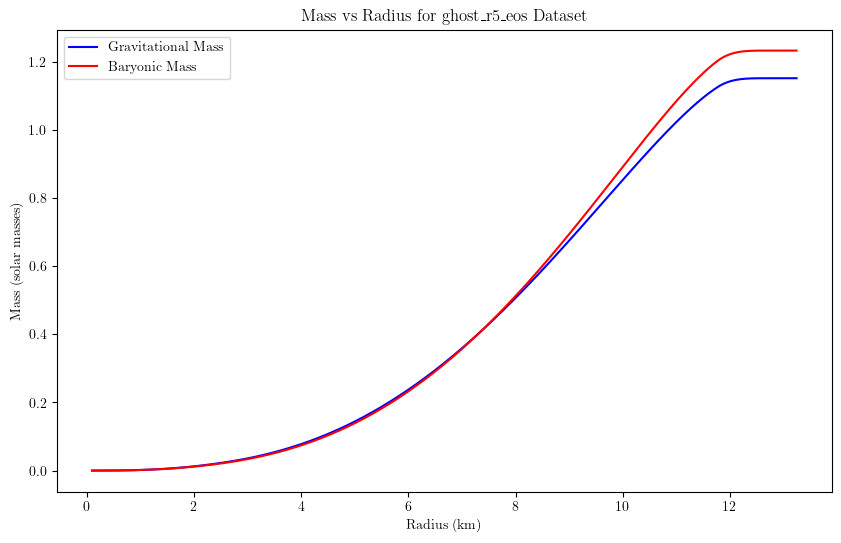

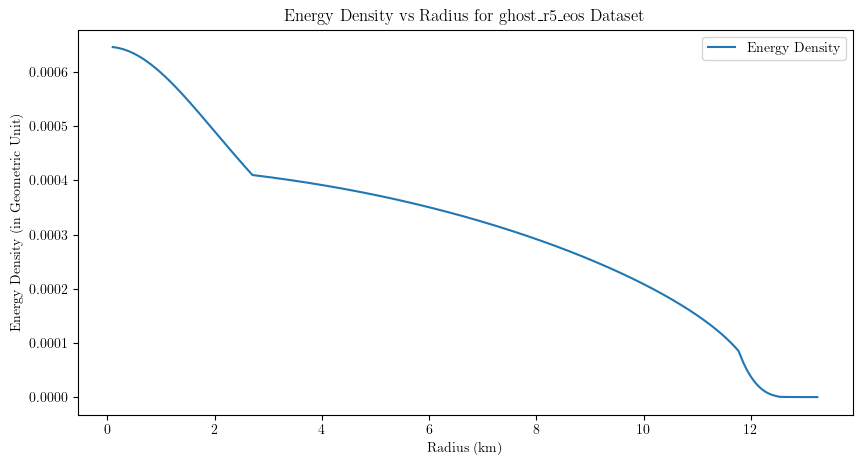

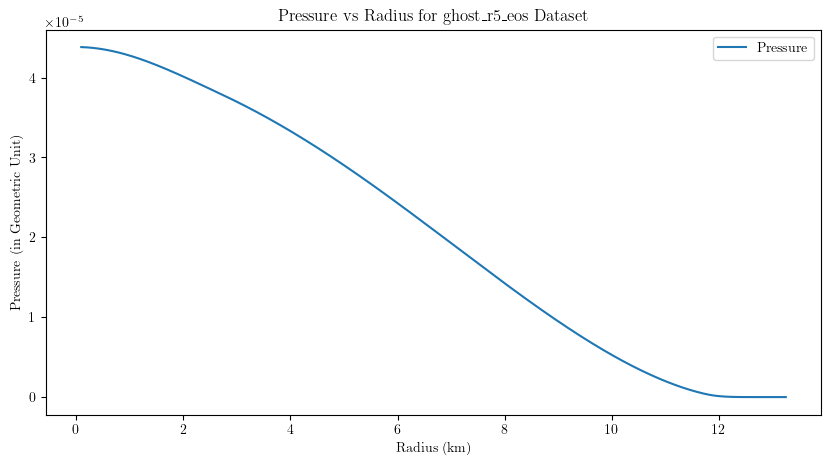

In [23]:
Solar_mass_in_km = 1.47662504
Rho0 = 58.68e-5
Pressure0 = Pressure_function(Rho0)
Epsilon0 =  Energy_Density_function(Pressure0)
Radius0 = 0.1                                         # Geometric Unit
Mass0 = (4 / 3) * mth.pi * (Radius0 ** 3) * Epsilon0  # Geometric Unit
h = 0.005
Pressure_Limit = 10 ** (-14)
MassB0 = Mb0(Rho0, Mass0, Radius0)  

MassB = [MassB0]
Mass = [Mass0]
Pressure = [Pressure0]
Epsilon = [Epsilon0]
Radius = [Radius0]
Rho = [Rho0]

# RK4 integration
while Pressure[-1] > Pressure_Limit:
    Coefficient = RK4_Slope(Mass[-1], MassB[-1], Pressure[-1], Epsilon[-1], Rho[-1], Radius[-1], h)
    Mass_i = Mass[-1] + h * Coefficient[0]
    MassB_i = MassB[-1] + h * Coefficient[1]
    Pressure_i = Pressure[-1] + h * Coefficient[2]
    Rho_i = Rho_function(Pressure_i)
    Epsilon_i = Energy_Density_function(Pressure_i)
    Radius_i = Radius[-1] + h

    MassB.append(MassB_i)
    Mass.append(Mass_i)
    Pressure.append(Pressure_i)
    Epsilon.append(Epsilon_i)
    Radius.append(Radius_i)
    Rho.append(Rho_i)

# Final results
MassB_star = MassB[-1]
Mass_star = Mass[-1]
Radius_star = Radius[-1]

print(f'Baryonic Mass of star: {MassB_star / Solar_mass_in_km} Solar masses')
print(f'Mass of star: {Mass_star / Solar_mass_in_km} Solar masses')
print(f'Radius of star: {Radius_star} km')

# Plotting results
Mass_1 = np.array(Mass)
Mass_2 = np.array(MassB)

plt.figure(figsize=(10, 6))
plt.plot(Radius, Mass_1 / Solar_mass_in_km, 'b-', label='Gravitational Mass')
plt.plot(Radius, Mass_2 / Solar_mass_in_km, 'r-', label='Baryonic Mass')
plt.xlabel('Radius (km)')
plt.ylabel('Mass (solar masses)')
plt.title('Mass vs Radius for ghost_r5_eos Dataset')
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(Radius, Epsilon, label='Energy Density')
plt.xlabel('Radius (km)')
plt.ylabel('Energy Density (in Geometric Unit)')
plt.title('Energy Density vs Radius for ghost_r5_eos Dataset')
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(Radius, Pressure, label='Pressure')
plt.xlabel('Radius (km)')
plt.ylabel('Pressure (in Geometric Unit)')
plt.title('Pressure vs Radius for ghost_r5_eos Dataset')
plt.legend()
plt.show()

/tmp/ipykernel_16342/38728230.py:57: RuntimeWarning: invalid value encountered in scalar power
  return (Pressure/K[0])**(1/Gamma_array[0])


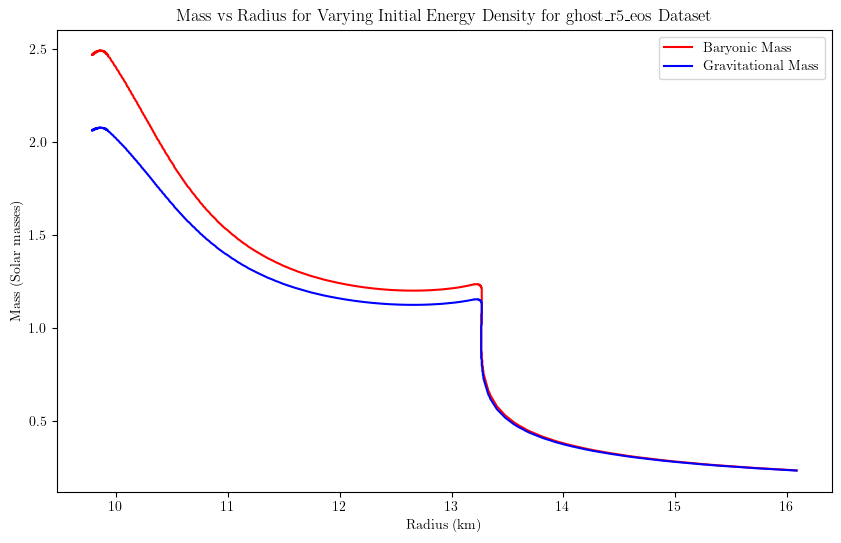

In [24]:
final_masses_ghost2 = []
final_radii_ghost2 = []
final_massb_ghost2 = []


Rho0_ghost2 = np.linspace(0.3, 4, 1000) * 58.68e-5
Pressure0_ghost2 = np.array([Pressure_function(i) for i in Rho0_ghost2])
Epsilon0_ghost2 = np.array([Energy_Density_function(i) for i in Pressure0_ghost2])


for n in Rho0_ghost2:
    
    Rho0 = n
    Pressure0 = Pressure_function(Rho0)
    Epsilon0 = Energy_Density_function(Pressure0)
    Radius0 = 0.1                                         # Geometric Unit
    Mass0 = (4 / 3) * mth.pi * (Radius0 ** 3) * Epsilon0  # Geometric Unit
    h = 0.005
    Pressure_Limit = 10 ** (-14)
    MassB0 = Mb0(Rho0, Mass0, Radius0)  


    MassB = [MassB0]
    Mass = [Mass0]
    Pressure = [Pressure0]
    Epsilon = [Epsilon0]
    Radius = [Radius0]
    Rho = [Rho0]

    
    while Pressure[-1] > Pressure_Limit:
        Coefficient = RK4_Slope(Mass[-1], MassB[-1], Pressure[-1], Epsilon[-1], Rho[-1], Radius[-1], h)
        Mass_i = Mass[-1] + h * Coefficient[0]
        MassB_i = MassB[-1] + h * Coefficient[1]
        Pressure_i = Pressure[-1] + h * Coefficient[2]
        Epsilon_i = Energy_Density_function(Pressure_i)
        Rho_i = Rho_function(Pressure_i)
        Radius_i = Radius[-1] + h

        MassB.append(MassB_i)
        Mass.append(Mass_i)
        Pressure.append(Pressure_i)
        Epsilon.append(Epsilon_i)
        Radius.append(Radius_i)
        Rho.append(Rho_i)

    final_massb_ghost2.append(MassB[-1] / Solar_mass_in_km)
    final_masses_ghost2.append(Mass[-1] / Solar_mass_in_km)
    final_radii_ghost2.append(Radius[-1])


plt.figure(figsize=(10, 6))
plt.plot(final_radii_ghost2, final_massb_ghost2, 'r-', label='Baryonic Mass')
plt.plot(final_radii_ghost2, final_masses_ghost2, 'b-', label='Gravitational Mass')
plt.xlabel('Radius (km)')
plt.ylabel('Mass (Solar masses)')
plt.title('Mass vs Radius for Varying Initial Energy Density for ghost_r5_eos Dataset')
plt.legend()
plt.show()

In [25]:
MR_ghost2 = []
for i in range(0,len(final_radii_ghost2)):
    Array_ghost2 = [Epsilon0_ghost2[i], Rho0_ghost2[i], Pressure0_ghost2[i], final_masses_ghost2[i], final_massb_ghost2[i], final_radii_ghost2[i]]
    MR_ghost2.append(Array_ghost2)
MR_ghost2 = np.array(MR_ghost2)
np.savetxt('MR_ghost2_Geometric ', MR_ghost2, delimiter = '\t', header = 'Epsilon0    Rho0    Pressure0    Gravitational Mass (Solar Masses)    Baryonic Mass (Solar Masses)    Radius' )

In [26]:
file_path = 'ghost_t2_eos.d'
Gamma_array = np.loadtxt(file_path, skiprows = 2, usecols = 0, max_rows = 9)
K0 = 6.8011 *10 **(-9)
LogRho = np.loadtxt(file_path, skiprows = 14, usecols = 0, max_rows = 8)
Rho_array = np.array([10**i for i in LogRho])  #in g cm-3


K = [K0] 
for i in range(1,len(Rho_array)+1):
    Ki = K[i-1]*((Rho_array[i-1])**(Gamma_array[i-1]-Gamma_array[i]))
    K.append(Ki)
    
for i in range(0,len(K)):
    K[i] *= (7.4237e-19)**(1-Gamma_array[i])
    
Rho_array = Rho_array*(7.4237e-19) 

def dmdr(Epsilon, Radius):
    return 4 * mth.pi * Epsilon * (Radius ** 2)

def dpdr(Epsilon, Pressure, Mass, Radius):
    return (-(Epsilon + Pressure) * (Mass + (4 * mth.pi * (Radius ** 3) * Pressure))) / (Radius * (Radius - (2 * Mass)))

def dMdr(Rho, Mass, Radius):
    return 4 * mth.pi * Rho * (Radius ** 2) * ((1 - 2 * Mass / Radius) ** (-1 / 2))

def Mb0(rho0, m0, r0):
    M = [m0]
    r = r0
    i = 0
    h = 0.005  # Step size
    while r <= r0:
        K_Mass_B_1 = dMdr(rho0, m0, r)
        K_Mass_B_2 = dMdr(rho0, m0, r + 0.5 * h)
        K_Mass_B_3 = dMdr(rho0, m0, r + 0.5 * h)
        K_Mass_B_4 = dMdr(rho0, m0, r + h)
        m = M[i] + ((1 / 6) * (K_Mass_B_1 + 2 * K_Mass_B_2 + 2 * K_Mass_B_3 + K_Mass_B_4))
        M.append(m)
        r += h
        i += 1
    return M[-1]

def Pressure_function(Rho): #in km-2
    for i in range(len(Rho_array) - 1): 
        if Rho>0 and Rho<=Rho_array[0]:
            return K[0] * (Rho ** Gamma_array[0])
        elif Rho_array[i] < Rho <= Rho_array[i + 1]:
            return K[i+1] * (Rho ** Gamma_array[i+1])
        elif Rho > Rho_array[-1]:
            return K[-1] * (Rho ** Gamma_array[-1])

Pressure_array = np.array([Pressure_function(i) for i in Rho_array])

def Rho_function(Pressure): #in km-2
    for i in range(len(Pressure_array)-1):
        if Pressure <=Pressure_array[0]:
            return (Pressure/K[0])**(1/Gamma_array[0])        
        elif Pressure_array[i] < Pressure <=Pressure_array[i+1]:
            return (Pressure/K[i+1])**(1/Gamma_array[i+1])
        elif Pressure > Pressure_array[-1]:
            return (Pressure/K[-1])**(1/Gamma_array[-1])
        
A_array = [0] #ai

for i in range(1,len(K)):
    ai = A_array[i-1] + ((Pressure_array[i-1]/Rho_array[i-1])*((1/(Gamma_array[i-1]-1))-(1/(Gamma_array[i]-1))))
    A_array.append(ai)

def Energy_Density_function(Pressure):
    for i in range(len(Pressure_array)-1):
        if Pressure <= Pressure_array[0]:
            return ((1+A_array[0]) * Rho_function(Pressure)+((K[0]*(Rho_function(Pressure)**(Gamma_array[0]))))/(Gamma_array[0]-1))
        elif Pressure_array[i] < Pressure <= Pressure_array[i+1]:
            return ((1+A_array[i+1])*Rho_function(Pressure))+((K[i+1]*(Rho_function(Pressure)**(Gamma_array[i+1])))/(Gamma_array[i+1]-1))
        elif Pressure >= Pressure_array[-1]:
            return ((1+A_array[-1])*Rho_function(Pressure))+((K[-1]*(Rho_function(Pressure)**(Gamma_array[-1])))/(Gamma_array[-1]-1))
    

def RK4_Slope(Mass, MassB, Pressure, Epsilon, Rho, Radius, h):
    k_Mass_1 = dmdr(Epsilon, Radius)
    k_Mass_B_1 = dMdr(Rho, Mass, Radius)
    k_Pressure_1 = dpdr(Epsilon, Pressure, Mass, Radius)
    k_Epsilon_1 = Energy_Density_function(Pressure)
    k_Rho_1 = Rho_function(Pressure)

    k_Mass_2 = dmdr(Epsilon + 0.5 * h * k_Epsilon_1, Radius + 0.5 * h)
    k_Mass_B_2 = dMdr(Rho + 0.5 * h * k_Rho_1, Mass + 0.5 * h * k_Mass_1, Radius + 0.5 * h)
    k_Pressure_2 = dpdr(Epsilon + 0.5 * h * k_Epsilon_1, Pressure + 0.5 * h * k_Pressure_1, Mass + 0.5 * h * k_Mass_1, Radius + 0.5 * h)
    k_Epsilon_2 = Energy_Density_function(Pressure + 0.5 * h * k_Pressure_1)
    k_Rho_2 = Rho_function(Pressure + 0.5 * h * k_Pressure_1)

    k_Mass_3 = dmdr(Epsilon + 0.5 * h * k_Epsilon_2, Radius + 0.5 * h)
    k_Mass_B_3 = dMdr(Rho + 0.5 * h * k_Rho_2, Mass + 0.5 * h * k_Mass_2, Radius + 0.5 * h)
    k_Pressure_3 = dpdr(Epsilon + 0.5 * h * k_Epsilon_2, Pressure + 0.5 * h * k_Pressure_2, Mass + 0.5 * h * k_Mass_2, Radius + 0.5 * h)
    k_Epsilon_3 = Energy_Density_function(Pressure + 0.5 * h * k_Pressure_2)
    k_Rho_3 = Rho_function(Pressure + 0.5 * h * k_Pressure_2)

    k_Mass_4 = dmdr(Epsilon + h * k_Epsilon_3, Radius + h)
    k_Mass_B_4 = dMdr(Rho + h * k_Rho_3, Mass + h * k_Mass_3, Radius + h)
    k_Pressure_4 = dpdr(Epsilon + h * k_Epsilon_3, Pressure + h * k_Pressure_3, Mass + h * k_Mass_3, Radius + h)
    k_Epsilon_4 = Energy_Density_function(Pressure + h * k_Pressure_3)
    k_Rho_4 = Rho_function(Pressure + h * k_Pressure_3)

    return [(1 / 6) * (k_Mass_1 + 2 * k_Mass_2 + 2 * k_Mass_3 + k_Mass_4),
            (1 / 6) * (k_Mass_B_1 + 2 * k_Mass_B_2 + 2 * k_Mass_B_3 + k_Mass_B_4),
            (1 / 6) * (k_Pressure_1 + 2 * k_Pressure_2 + 2 * k_Pressure_3 + k_Pressure_4),
           ]

print(f'Pressure points: {Pressure_array}')
print(f'Rest Mass Density in Geometric Unit: {Rho_array}')
print(f'Values of K: {K}')
print(f'Values of Gamma: {Gamma_array}')
print(f'Values of A: {A_array}')

Pressure points: [2.53423166e-15 6.31228076e-10 2.11053544e-09 3.26787298e-07
 4.24123567e-06 8.58322532e-05 1.05152232e-04 5.66297250e-04]
Rest Mass Density in Geometric Unit: [1.80395910e-11 2.80615860e-07 1.95243310e-06 8.02474885e-05
 2.18416699e-04 3.99231404e-04 1.10170319e-03 1.88736074e-03]
Values of K: [265.86990727912604, 0.1716437570024778, 7.532990936174701e-06, 0.11792993104977989, 9975.178056183011, 7614538155107.649, 0.00041058735866554124, 187651.92608995023, 1938885.847137698]
Values of Gamma: [1.58425 1.28733 0.62223 1.35692 2.56    4.9865  0.2     3.1277  3.5    ]
Values of A: [0, -0.0002484731031396745, 0.013534807667054633, 0.0076447131154282425, 0.016443701451340706, 0.024020234028379547, 0.34669286123579346, 0.1825280463887744, 0.20352866892863095]


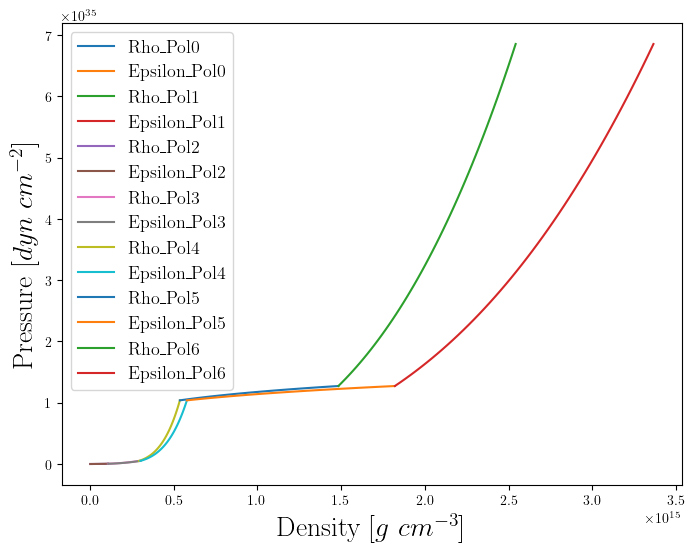

In [27]:
arrs = []
ep_gh = [Energy_Density_function(i) for i in Pressure_array]
ep_arrs = []
for s in range(1,len(Rho_array)):
    a = np.linspace(Rho_array[s-1], Rho_array[s])
    b = np.linspace(ep_gh[s-1], ep_gh[s])
    arrs.append(a)
    ep_arrs.append(b)
ps = []

for t in range(0,len(arrs)):
    P = []
    for v in arrs[t]:
        P.append(K[t+1]*(v**Gamma_array[t+1]))
    ps.append(P)
plt.figure(figsize=(8, 6))

for w in range(0, len(arrs)):
    arrs_np = np.array(arrs[w])
    ep_arrs_np = np.array(ep_arrs[w])
    ps_np = np.array(ps[w])
    plt.plot(arrs_np / (7.4237 * 1e-19), ps_np / (8.2601 * 1e-40), label=f'Rho_Pol{w}')
    plt.plot(ep_arrs_np / (7.4237 * 1e-19), ps_np / (8.2601 * 1e-40), label=f'Epsilon_Pol{w}')


plt.ylabel('Pressure  [$dyn\ cm^{-2}$]', fontsize=20)
plt.xlabel('Density  [$ g\ cm^{-3} $]', fontsize=20)
# plt.title('Piece-Wise Polytrop for t2 Dataset')
plt.legend(fontsize=13)
plt.savefig('Piece-wise_t2.pdf', format='pdf',bbox_inches="tight")
plt.show()


Baryonic Mass of star: 2.2688372105186176 Solar masses
Mass of star: 1.9901833095654424 Solar masses
Radius of star: 13.955000000000782 km


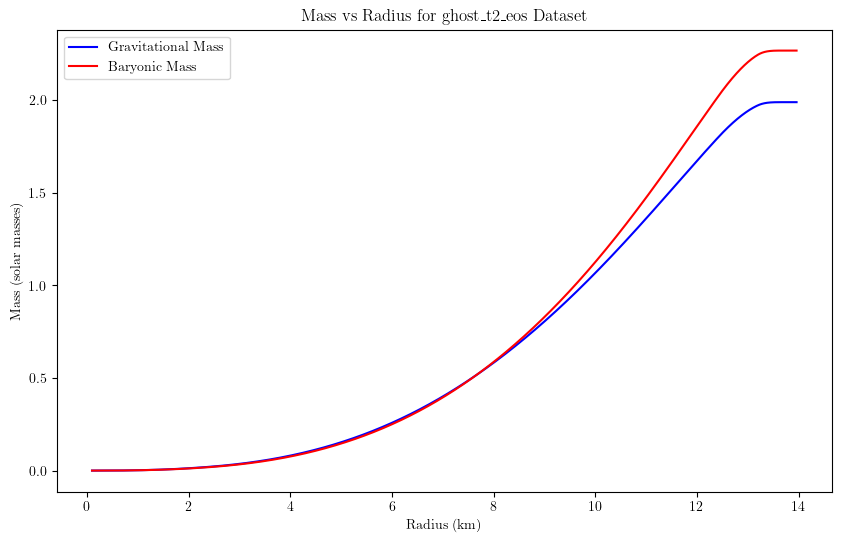

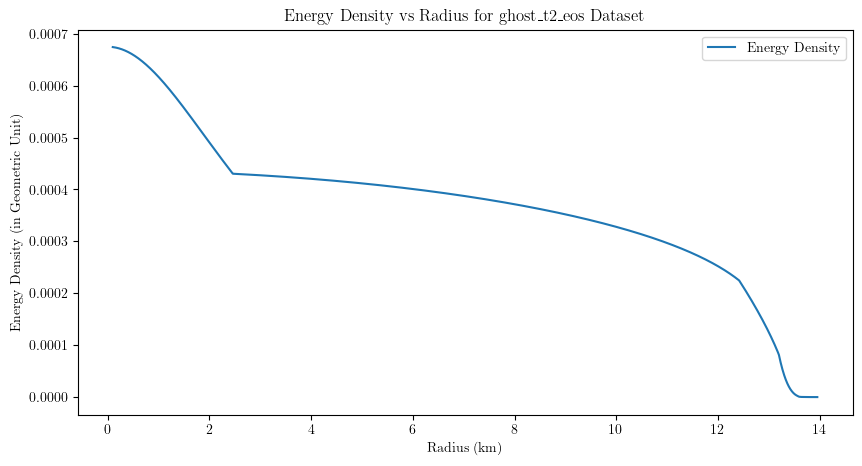

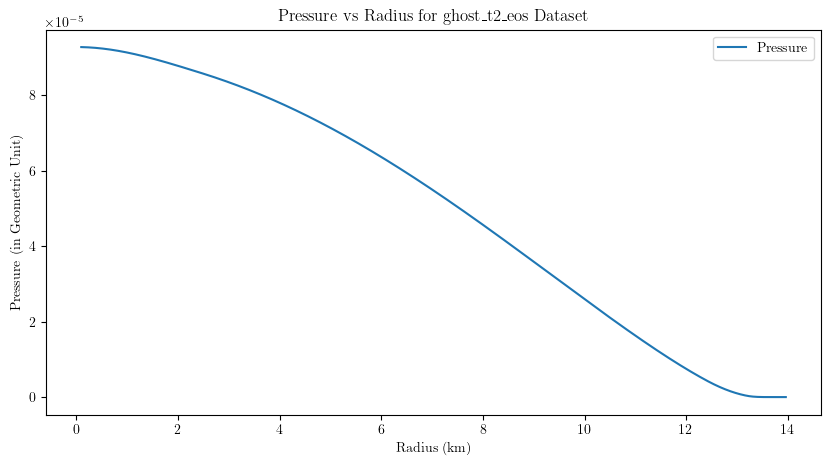

In [28]:
Solar_mass_in_km = 1.47662504
Rho0 = 58.68e-5
Pressure0 = Pressure_function(Rho0)
Epsilon0 = Energy_Density_function(Pressure0)
Radius0 = 0.1                                         # Geometric Unit
Mass0 = (4 / 3) * mth.pi * (Radius0 ** 3) * Epsilon0  # Geometric Unit
h = 0.005
Pressure_Limit = 10 ** (-14)
MassB0 = Mb0(Rho0, Mass0, Radius0)  

MassB = [MassB0]
Mass = [Mass0]
Pressure = [Pressure0]
Epsilon = [Epsilon0]
Radius = [Radius0]
Rho = [Rho0]


while Pressure[-1] > Pressure_Limit:
    Coefficient = RK4_Slope(Mass[-1], MassB[-1], Pressure[-1], Epsilon[-1], Rho[-1], Radius[-1], h)
    Mass_i = Mass[-1] + h * Coefficient[0]
    MassB_i = MassB[-1] + h * Coefficient[1]
    Pressure_i = Pressure[-1] + h * Coefficient[2]
    Rho_i = Rho_function(Pressure_i)
    Epsilon_i = Energy_Density_function(Pressure_i)
    Radius_i = Radius[-1] + h

    MassB.append(MassB_i)
    Mass.append(Mass_i)
    Pressure.append(Pressure_i)
    Epsilon.append(Epsilon_i)
    Radius.append(Radius_i)
    Rho.append(Rho_i)

MassB_star = MassB[-1]
Mass_star = Mass[-1]
Radius_star = Radius[-1]

print(f'Baryonic Mass of star: {MassB_star / Solar_mass_in_km} Solar masses')
print(f'Mass of star: {Mass_star / Solar_mass_in_km} Solar masses')
print(f'Radius of star: {Radius_star} km')

Mass_1 = np.array(Mass)
Mass_2 = np.array(MassB)

plt.figure(figsize=(10, 6))
plt.plot(Radius, Mass_1 / Solar_mass_in_km, 'b-', label='Gravitational Mass')
plt.plot(Radius, Mass_2 / Solar_mass_in_km, 'r-', label='Baryonic Mass')
plt.xlabel('Radius (km)')
plt.ylabel('Mass (solar masses)')
plt.title('Mass vs Radius for ghost_t2_eos Dataset')
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(Radius, Epsilon, label='Energy Density')
plt.xlabel('Radius (km)')
plt.ylabel('Energy Density (in Geometric Unit)')
plt.title('Energy Density vs Radius for ghost_t2_eos Dataset')
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(Radius, Pressure, label='Pressure')
plt.xlabel('Radius (km)')
plt.ylabel('Pressure (in Geometric Unit)')
plt.title('Pressure vs Radius for ghost_t2_eos Dataset')
plt.legend()
plt.show()

/tmp/ipykernel_16342/154593182.py:57: RuntimeWarning: invalid value encountered in scalar power
  return (Pressure/K[0])**(1/Gamma_array[0])


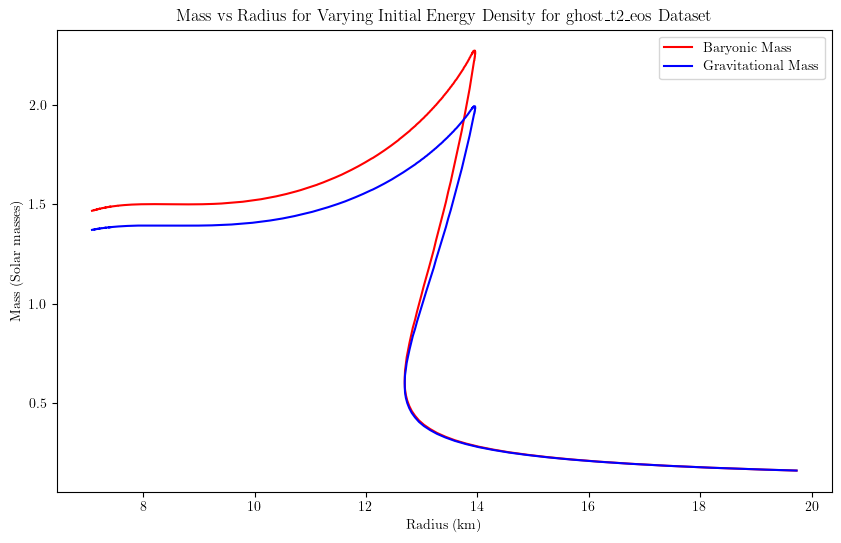

In [29]:
final_masses_ghost3 = []
final_radii_ghost3 = []
final_massb_ghost3 = []


Rho0_ghost3 = np.linspace(0.3, 6, 1000) * 58.68e-5
Pressure0_ghost3 = np.array([Pressure_function(i) for i in Rho0_ghost3])
Epsilon0_ghost3 = np.array([Energy_Density_function(i) for i in Pressure0_ghost3])


for n in Rho0_ghost3:
    
    Rho0 = n
    Pressure0 = Pressure_function(Rho0)
    Epsilon0 = Energy_Density_function(Pressure0)
    Radius0 = 0.1                                         # Geometric Unit
    Mass0 = (4 / 3) * mth.pi * (Radius0 ** 3) * Epsilon0  # Geometric Unit
    h = 0.005
    Pressure_Limit = 10 ** (-14)
    MassB0 = Mb0(Rho0, Mass0, Radius0)  


    MassB = [MassB0]
    Mass = [Mass0]
    Pressure = [Pressure0]
    Epsilon = [Epsilon0]
    Radius = [Radius0]
    Rho = [Rho0]

    
    while Pressure[-1] > Pressure_Limit:
        Coefficient = RK4_Slope(Mass[-1], MassB[-1], Pressure[-1], Epsilon[-1], Rho[-1], Radius[-1], h)
        Mass_i = Mass[-1] + h * Coefficient[0]
        MassB_i = MassB[-1] + h * Coefficient[1]
        Pressure_i = Pressure[-1] + h * Coefficient[2]
        Epsilon_i = Energy_Density_function(Pressure_i)
        Rho_i = Rho_function(Pressure_i)
        Radius_i = Radius[-1] + h

        MassB.append(MassB_i)
        Mass.append(Mass_i)
        Pressure.append(Pressure_i)
        Epsilon.append(Epsilon_i)
        Radius.append(Radius_i)
        Rho.append(Rho_i)

    final_massb_ghost3.append(MassB[-1] / Solar_mass_in_km)
    final_masses_ghost3.append(Mass[-1] / Solar_mass_in_km)
    final_radii_ghost3.append(Radius[-1])


plt.figure(figsize=(10, 6))
plt.plot(final_radii_ghost3, final_massb_ghost3, 'r-', label='Baryonic Mass')
plt.plot(final_radii_ghost3, final_masses_ghost3, 'b-', label='Gravitational Mass')
plt.xlabel('Radius (km)')
plt.ylabel('Mass (Solar masses)')
plt.title('Mass vs Radius for Varying Initial Energy Density for ghost_t2_eos Dataset')
plt.legend()
plt.show()

In [30]:
MR_ghost3 = []
for i in range(0,len(final_radii_ghost3)):
    Array_ghost3 = [Epsilon0_ghost3[i], Rho0_ghost3[i], Pressure0_ghost3[i], final_masses_ghost3[i], final_massb_ghost3[i], final_radii_ghost3[i]]
    MR_ghost3.append(Array_ghost3)
MR_ghost3 = np.array(MR_ghost3)
np.savetxt('MR_ghost3_Geometric ', MR_ghost3, delimiter = '\t', header = 'Epsilon0    Rho0    Pressure0    Gravitational Mass (Solar Masses)    Baryonic Mass (Solar Masses)    Radius' )

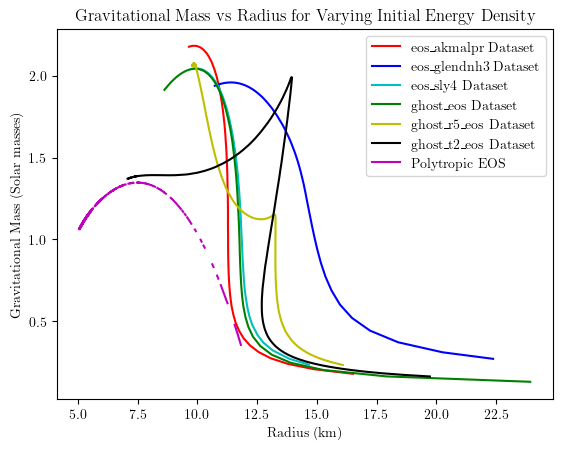

In [31]:
plt.plot(final_radii_a, final_masses_a, 'r-', label='eos_akmalpr Dataset')
plt.plot(final_radii_g, final_masses_g, 'b-', label='eos_glendnh3 Dataset')
plt.plot(final_radii_s, final_masses_s, 'c-', label='eos_sly4 Dataset')
plt.plot(final_radii_ghost1, final_masses_ghost1, 'g-', label='ghost_eos Dataset')
plt.plot(final_radii_ghost2, final_masses_ghost2, 'y-', label='ghost_r5_eos Dataset')
plt.plot(final_radii_ghost3, final_masses_ghost3, 'k-', label='ghost_t2_eos Dataset')
plt.plot(final_radii_pol, final_masses_pol, 'm-', label='Polytropic EOS')
plt.xlabel('Radius (km)')
plt.ylabel('Gravitational Mass (Solar masses)')
plt.title('Gravitational Mass vs Radius for Varying Initial Energy Density')
# plt.savefig('MR for Gravational Mass')
plt.legend()
plt.show()

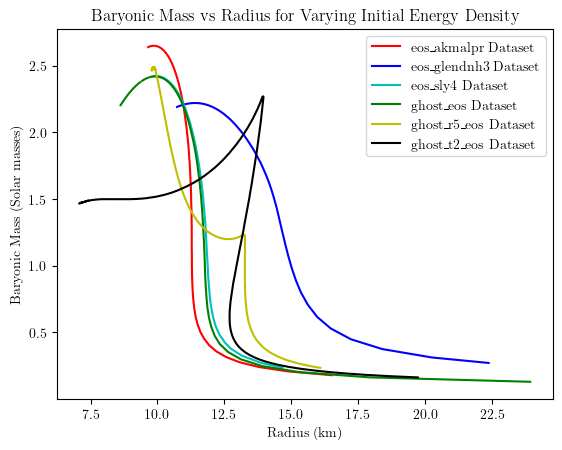

In [32]:
plt.plot(final_radii_a, final_massb_a, 'r-', label='eos_akmalpr Dataset')
plt.plot(final_radii_g, final_massb_g, 'b-', label='eos_glendnh3 Dataset')
plt.plot(final_radii_s, final_massb_s, 'c-', label='eos_sly4 Dataset')
plt.plot(final_radii_ghost1, final_massb_ghost1, 'g-', label='ghost_eos Dataset')
plt.plot(final_radii_ghost2, final_massb_ghost2, 'y-', label='ghost_r5_eos Dataset')
plt.plot(final_radii_ghost3, final_massb_ghost3, 'k-', label='ghost_t2_eos Dataset')
plt.xlabel('Radius (km)')
plt.ylabel('Baryonic Mass (Solar masses)')
plt.title('Baryonic Mass vs Radius for Varying Initial Energy Density')
#  
plt.legend()
plt.show()

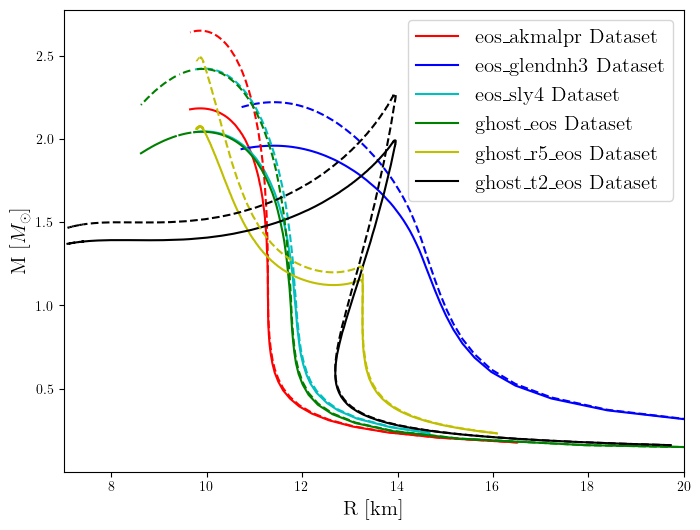

In [33]:
plt.figure(figsize=(8, 6))
plt.plot(final_radii_a, final_masses_a, 'r-', label='eos_akmalpr Dataset')
plt.plot(final_radii_g, final_masses_g, 'b-', label='eos_glendnh3 Dataset')
plt.plot(final_radii_s, final_masses_s, 'c-', label='eos_sly4 Dataset')
plt.plot(final_radii_a, final_massb_a, 'r', linestyle='dashed')
plt.plot(final_radii_g, final_massb_g, 'b', linestyle='dashed')
plt.plot(final_radii_s, final_massb_s, 'c', linestyle='dashed')
plt.plot(final_radii_ghost1, final_masses_ghost1, 'g-', label='ghost_eos Dataset')
plt.plot(final_radii_ghost2, final_masses_ghost2, 'y-', label='ghost_r5_eos Dataset')
plt.plot(final_radii_ghost3, final_masses_ghost3, 'k-', label='ghost_t2_eos Dataset')
plt.plot(final_radii_ghost1, final_massb_ghost1, 'g', linestyle='dashed')
plt.plot(final_radii_ghost2, final_massb_ghost2, 'y', linestyle='dashed')
plt.plot(final_radii_ghost3, final_massb_ghost3, 'k', linestyle='dashed')
plt.xlabel('R [km]', fontsize=15)
plt.ylabel('M $[M_{\odot}]$', fontsize=15)
plt.xlim(7, 20)
# plt.title('MR Curve')
plt.legend(fontsize=15)
plt.savefig('MR_all.pdf', format='pdf',bbox_inches="tight")
plt.show()


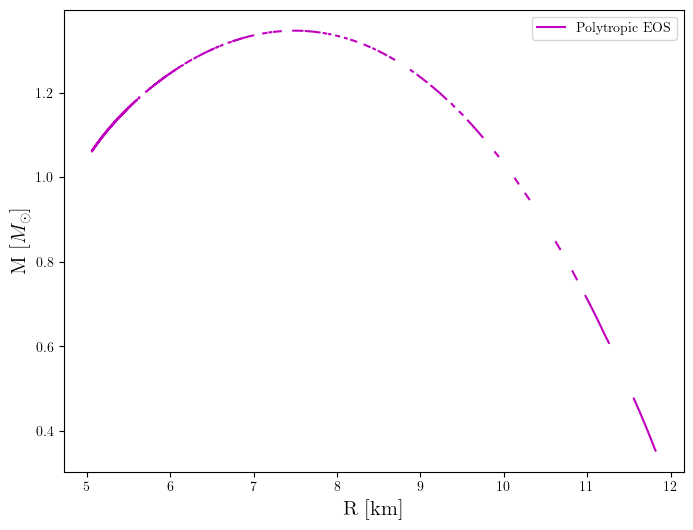

In [34]:
plt.figure(figsize=(8, 6))
plt.plot(final_radii_pol, final_masses_pol, 'm-', label='Polytropic EOS')
plt.xlabel('R [km]', fontsize=15)
plt.ylabel('M $[M_{\odot}]$', fontsize=15)
# plt.title('MR Curve')
plt.legend()
plt.savefig('MR_pol.pdf', format='pdf',bbox_inches="tight")
plt.show()


In [35]:
#Dataset from WhiskyTHC (r5)

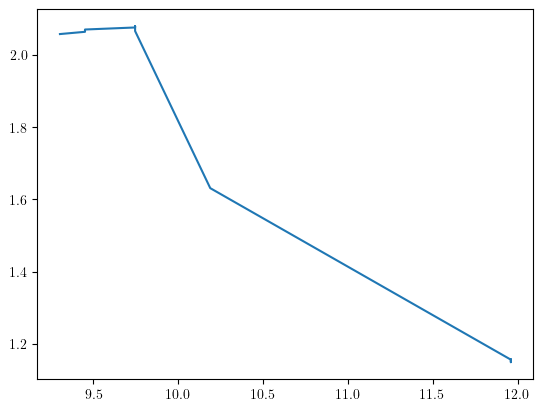

In [36]:
data_r = """
10    8.90e17    0.144652635143397    8.1
12    6.76e17    0.143644050342718    8.1
13    9.97e17    0.144512733127319    8.1
14    1.31e18    0.203890506568765    6.9
15    1.64e18    0.258273040246433    6.6
16    1.96e18    0.259794055592655    6.6
17    2.28e18    0.259957968464531    6.6
18    2.60e18    0.259508307097494    6.6
19    2.92e18    0.258802114894928    6.4
20    3.24e18    0.258008995850343    6.4
21    3.56e18    0.257229352151347    6.3
"""
data_r = np.array([row.split() for row in data_r.strip().split('\n')], dtype=float)
serial_number = data_r[:, 0]
central_mass_density = data_r[:, 1]
Mass_r = data_r[:, 2] * 8
Radius_r = data_r[:, 3] * Solar_mass_in_km

plt.plot(Radius_r, Mass_r)

[13.43728786 13.43728786 13.43728786 13.43728786 12.99430035 11.96066282
 10.9270253  10.18871278  9.30273775  8.71208774  8.26910022] [1.99867549 1.98877045 1.99803513 1.99075374 1.88413474 1.66762138
 1.51908483 1.43887871 1.40425416 1.39688104 1.39726083]


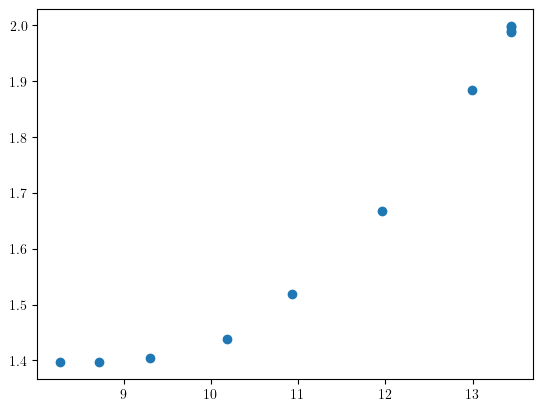

In [37]:
data_t = """
30    8.90e17    0.249834436143423    9.1
32    6.76e17    0.248596305819010    9.1
33    9.97e17    0.249754391475898    9.1
34    1.31e18    0.248844217102694    9.1
35    1.64e18    0.235516842579389    8.8
36    1.96e18    0.208452672050486    8.1
37    2.28e18    0.189885604373828    7.4
38    2.60e18    0.179859838376634    6.9
39    2.92e18    0.175531769882045    6.3
40    3.24e18    0.174610129524420    5.9
41    3.56e18    0.174657604365969    5.6
"""
data_t = np.array([row.split() for row in data_t.strip().split('\n')], dtype=float)
serial_number = data_t[:, 0]
central_mass_density = data_t[:, 1]
Mass_t = data_t[:, 2] * 8
Radius_t = data_t[:, 3] * Solar_mass_in_km

print(Radius_t, Mass_t)

plt.scatter(Radius_t, Mass_t)

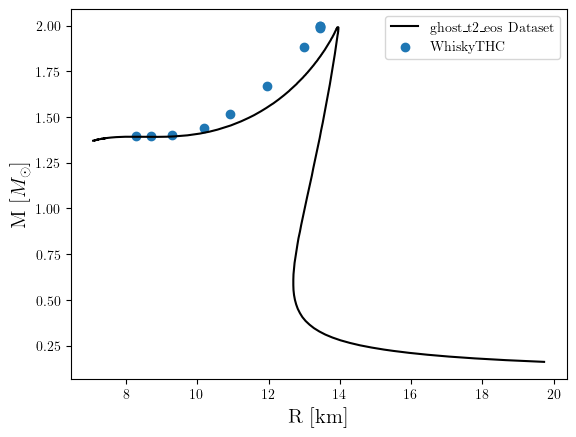

In [38]:
plt.plot(final_radii_ghost3, final_masses_ghost3, 'k-', label='ghost_t2_eos Dataset')
plt.scatter(Radius_t, Mass_t, label='WhiskyTHC')
plt.xlabel('R [km]', fontsize=15)
plt.ylabel('M $[M_{\odot}]$', fontsize=15)
plt.legend()
plt.savefig('MR_Com_t2.pdf', format='pdf',bbox_inches="tight")
plt.show()

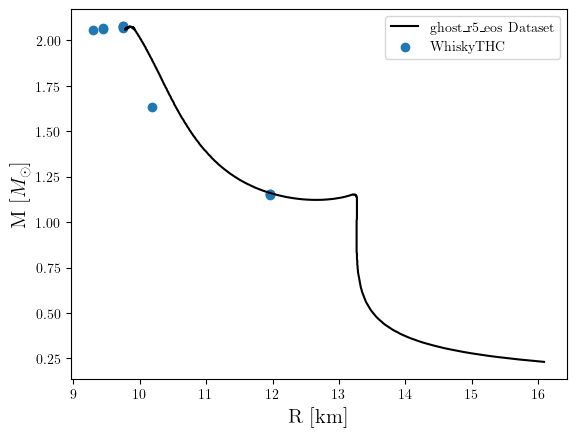

In [39]:
plt.plot(final_radii_ghost2, final_masses_ghost2, 'k-', label='ghost_r5_eos Dataset')
plt.scatter(Radius_r, Mass_r, label='WhiskyTHC')
plt.xlabel('R [km]', fontsize=15)
plt.ylabel('M $[M_{\odot}]$', fontsize=15)
plt.legend()
plt.savefig('MR_Com_r5.pdf', format='pdf',bbox_inches="tight")
plt.show()